<a href="https://colab.research.google.com/github/rickzzim/Pr-tica-5/blob/main/Pratica5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

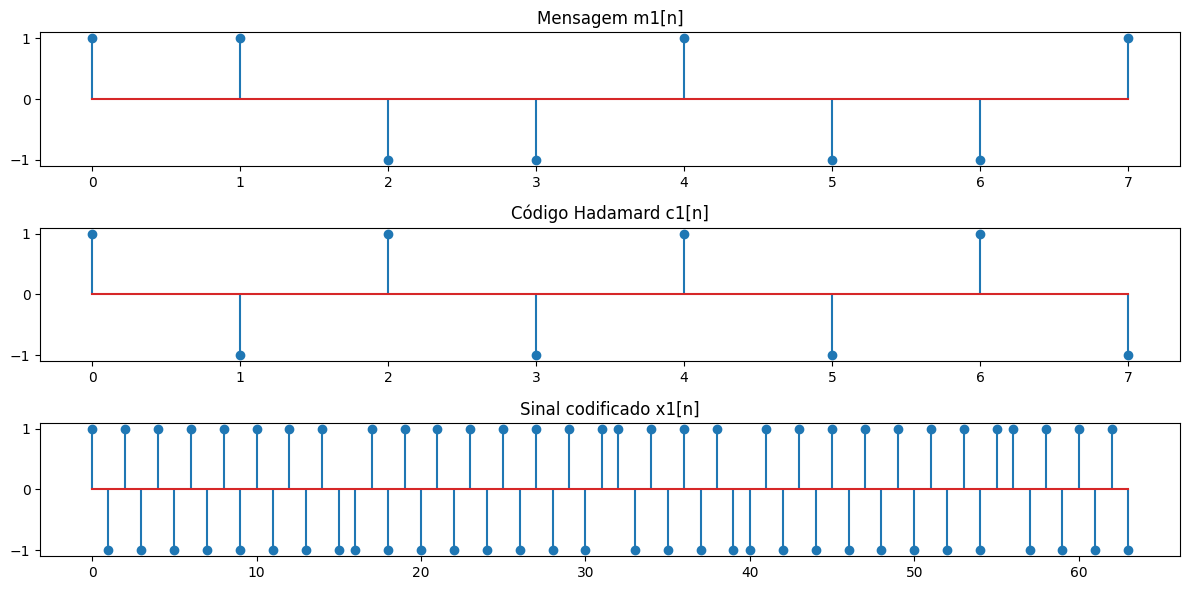

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Função para gerar matriz de Hadamard
def hadamard_matrix(n):
    if n == 1:
        return np.array([[1]])
    else:
        H = hadamard_matrix(n//2)
        return np.block([[H, H],[H, -H]])

# Número de chips (comprimento do código)
N = 8
H = hadamard_matrix(N)

# Selecionando 3 códigos ortogonais (linhas da matriz)
c1, c2, c3 = H[1], H[2], H[3]

# Mensagens dos usuários (sequências binárias em {-1,1})
m1 = np.random.choice([-1,1], size=8)
m2 = np.random.choice([-1,1], size=8)
m3 = np.random.choice([-1,1], size=8)

# Codificação: espalhamento espectral
x1 = np.kron(m1, c1)
x2 = np.kron(m2, c2)
x3 = np.kron(m3, c3)

# Plotando sinais originais e codificados
plt.figure(figsize=(12,6))
plt.subplot(3,1,1); plt.stem(m1); plt.title("Mensagem m1[n]")
plt.subplot(3,1,2); plt.stem(c1); plt.title("Código Hadamard c1[n]")
plt.subplot(3,1,3); plt.stem(x1); plt.title("Sinal codificado x1[n]")
plt.tight_layout()
plt.show()


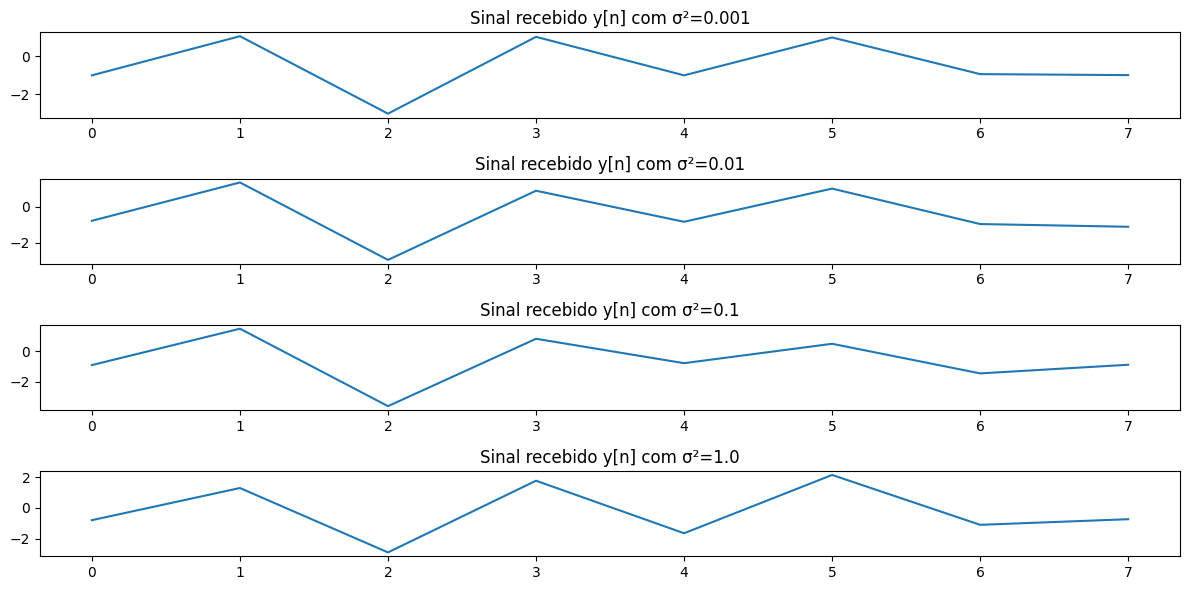

In [22]:
def awgn(signal, sigma2):
    noise = np.random.normal(0, np.sqrt(sigma2), len(signal))
    return signal + noise

# Sinal recebido
y_clean = x1 + x2 + x3

# Diferentes variâncias de ruído
sigmas = [1e-3, 1e-2, 1e-1,1e-0]

plt.figure(figsize=(12,6))
for i, s2 in enumerate(sigmas):
    y = awgn(y_clean, s2)
    plt.subplot(len(sigmas),1,i+1)
    plt.plot(y)
    plt.title(f"Sinal recebido y[n] com σ²={s2}")
plt.tight_layout()
plt.show()


In [5]:
# Decodificação: correlação com o código Hadamard
def decode(y, code, N):
    y_blocks = y.reshape(-1, N)
    return np.sign(np.sum(y_blocks * code, axis=1))

# Recuperando mensagens
m1_hat = decode(y_clean, c1, N)
m2_hat = decode(y_clean, c2, N)
m3_hat = decode(y_clean, c3, N)

print("Mensagem original m1:", m1)
print("Mensagem estimada m1_hat:", m1_hat)


Mensagem original m1: [ 1  1 -1 -1  1 -1 -1  1]
Mensagem estimada m1_hat: [ 1  1 -1 -1  1 -1 -1  1]


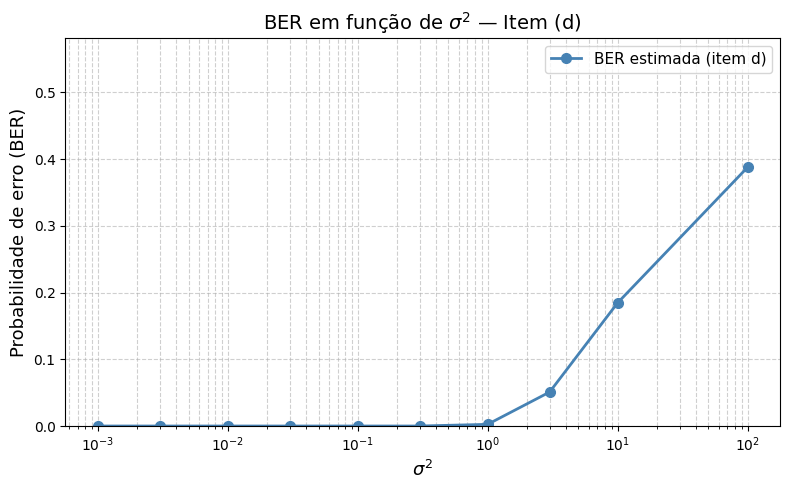


        σ² |        BER
-------------------------
    0.0010 |   0.000000
    0.0030 |   0.000000
    0.0100 |   0.000000
    0.0300 |   0.000000
    0.1000 |   0.000000
    0.3000 |   0.000000
    1.0000 |   0.002508
    3.0000 |   0.050925
   10.0000 |   0.184550
  100.0000 |   0.387767


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

# ──────────────────────────────────────────────
# 1. CONFIGURAÇÕES GERAIS
# ──────────────────────────────────────────────
np.random.seed(42)
N = 5000          # número de realizações Monte Carlo
L = 8             # comprimento do código Hadamard
H = hadamard(L)   # matriz de Hadamard 8×8

# Valores de σ² pedidos no enunciado
sigma2_values = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 100]

# ──────────────────────────────────────────────
# 2. CÓDIGOS DE HADAMARD (uma linha por usuário)
# ──────────────────────────────────────────────
c1 = H[0]   # código do usuário 1
c2 = H[1]   # código do usuário 2
c3 = H[2]   # código do usuário 3

# ──────────────────────────────────────────────
# 3. CÁLCULO DA BER — ITEM (d)
#
#    Modelo correto:
#    - Cada bit m_k[n] ∈ {-1,+1} é espalhado pelo código c_k (vetor L×1)
#    - O sinal transmitido no instante n é: s[n] = c1*m1[n] + c2*m2[n] + c3*m3[n]
#    - Recebido: y[n] = s[n] + w[n],  w[n] ~ N(0, σ²·I_L)
#    - Decodificação: m̂_k[n] = sign(c_k^T · y[n])
#      (sem dividir por L — o sinal resultante já tem magnitude L para bit correto)
# ──────────────────────────────────────────────
ber_d = []

for s2 in sigma2_values:
    erros = 0
    total = 0

    for _ in range(N):
        # Gera bits aleatórios para os 3 usuários (L bits cada)
        m1 = np.random.choice([-1, 1], size=L)
        m2 = np.random.choice([-1, 1], size=L)
        m3 = np.random.choice([-1, 1], size=L)

        for n in range(L):
            # Sinal transmitido (spreading) no instante n
            s = c1 * m1[n] + c2 * m2[n] + c3 * m3[n]

            # Ruído AWGN
            w = np.random.normal(0, np.sqrt(s2), size=L)

            # Sinal recebido
            y = s + w

            # Decodificação por projeção (correlação com cada código)
            m1_hat = np.sign(c1 @ y)
            m2_hat = np.sign(c2 @ y)
            m3_hat = np.sign(c3 @ y)

            # Contagem de erros (comparação escalar × escalar)
            erros += int(m1_hat != m1[n])
            erros += int(m2_hat != m2[n])
            erros += int(m3_hat != m3[n])
            total += 3

    ber_d.append(erros / total)

# ──────────────────────────────────────────────
# 4. PLOT
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(sigma2_values, ber_d, 'o-', color='steelblue',
            linewidth=2, markersize=7, label='BER estimada (item d)')

ax.set_xlabel(r'$\sigma^2$', fontsize=13)
ax.set_ylabel('Probabilidade de erro (BER)', fontsize=13)
ax.set_title(r'BER em função de $\sigma^2$ — Item (d)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.set_ylim([0, max(max(ber_d) * 1.5, 0.05)])

plt.tight_layout()
plt.savefig('ber_item_d_corrigido.png', dpi=150)
plt.show()

# ──────────────────────────────────────────────
# 5. TABELA DE RESULTADOS
# ──────────────────────────────────────────────
print(f"\n{'σ²':>10} | {'BER':>10}")
print("-" * 25)
for s2, b in zip(sigma2_values, ber_d):
    print(f"{s2:>10.4f} | {b:>10.6f}")

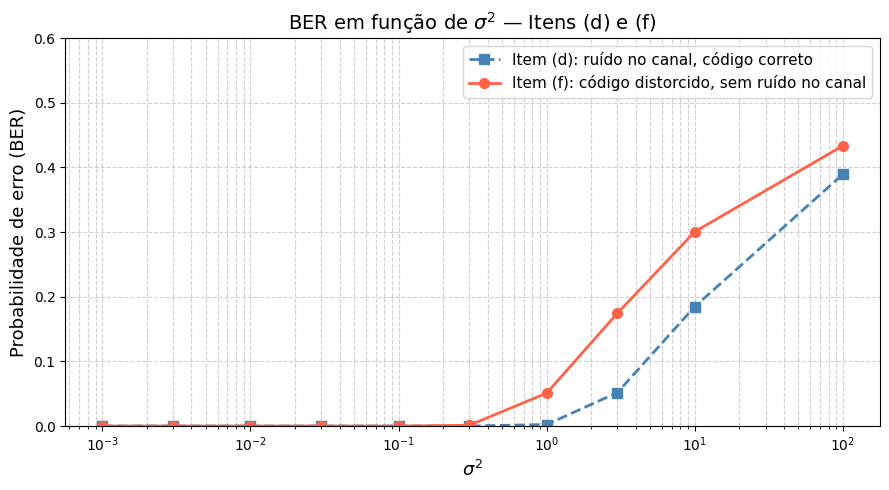


        σ² |    BER (d) |    BER (f)
-------------------------------------
    0.0010 |   0.000000 |   0.000000
    0.0030 |   0.000000 |   0.000000
    0.0100 |   0.000000 |   0.000000
    0.0300 |   0.000000 |   0.000000
    0.1000 |   0.000000 |   0.000000
    0.3000 |   0.000000 |   0.001142
    1.0000 |   0.002300 |   0.050900
    3.0000 |   0.051733 |   0.174483
   10.0000 |   0.184750 |   0.300558
  100.0000 |   0.389492 |   0.433550


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

# ──────────────────────────────────────────────
# 1. CONFIGURAÇÕES GERAIS
# ──────────────────────────────────────────────
np.random.seed(42)
N = 5000          # realizações Monte Carlo
L = 8             # tamanho do código Hadamard
H = hadamard(L)   # matriz de Hadamard 8×8

# Valores de σ² (mesmos da letra d para comparação)
sigma2_values = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 100]

# ──────────────────────────────────────────────
# 2. CÓDIGOS DE HADAMARD VERDADEIROS (transmissor)
# ──────────────────────────────────────────────
c1 = H[0]
c2 = H[1]
c3 = H[2]

# ──────────────────────────────────────────────
# 3. CÁLCULO DA BER — ITEM (f)
#
#    Cenário:
#    - w[n] = 0 (sem ruído no canal)
#    - Receptor usa Ĉ = C + W, onde W ~ N(0, σ²·I)
#    - ĉ_k = c_k + w_k  (código distorcido do usuário k)
#
#    Decodificação no receptor:
#    m̂_k[n] = sign(ĉ_k^T · y[n])
#            = sign((c_k + w_k)^T · y[n])
#
#    Com w[n]=0: y[n] = c1*m1[n] + c2*m2[n] + c3*m3[n]  (sem ruído de canal)
# ──────────────────────────────────────────────
ber_f = []

for s2 in sigma2_values:
    erros = 0
    total = 0

    for _ in range(N):
        # Bits aleatórios dos 3 usuários
        m1 = np.random.choice([-1, 1], size=L)
        m2 = np.random.choice([-1, 1], size=L)
        m3 = np.random.choice([-1, 1], size=L)

        # Distorção na matriz de códigos: W ~ N(0, σ²·I)
        # Cada linha de W é o erro no código de cada usuário
        w_c1 = np.random.normal(0, np.sqrt(s2), size=L)
        w_c2 = np.random.normal(0, np.sqrt(s2), size=L)
        w_c3 = np.random.normal(0, np.sqrt(s2), size=L)

        # Códigos distorcidos disponíveis no receptor
        c1_hat = c1 + w_c1
        c2_hat = c2 + w_c2
        c3_hat = c3 + w_c3

        for n in range(L):
            # Sinal transmitido (sem ruído de canal: w[n] = 0)
            y = c1 * m1[n] + c2 * m2[n] + c3 * m3[n]

            # Decodificação com código distorcido
            m1_hat = np.sign(c1_hat @ y)
            m2_hat = np.sign(c2_hat @ y)
            m3_hat = np.sign(c3_hat @ y)

            # Contagem de erros
            erros += int(m1_hat != m1[n])
            erros += int(m2_hat != m2[n])
            erros += int(m3_hat != m3[n])
            total += 3

    ber_f.append(erros / total)

# ──────────────────────────────────────────────
# 4. RECALCULA BER DO ITEM (d) PARA COMPARAÇÃO
#    (receptor com código correto, canal com ruído)
# ──────────────────────────────────────────────
ber_d = []

for s2 in sigma2_values:
    erros = 0
    total = 0

    for _ in range(N):
        m1 = np.random.choice([-1, 1], size=L)
        m2 = np.random.choice([-1, 1], size=L)
        m3 = np.random.choice([-1, 1], size=L)

        for n in range(L):
            s = c1 * m1[n] + c2 * m2[n] + c3 * m3[n]
            w = np.random.normal(0, np.sqrt(s2), size=L)
            y = s + w

            m1_hat = np.sign(c1 @ y)
            m2_hat = np.sign(c2 @ y)
            m3_hat = np.sign(c3 @ y)

            erros += int(m1_hat != m1[n])
            erros += int(m2_hat != m2[n])
            erros += int(m3_hat != m3[n])
            total += 3

    ber_d.append(erros / total)

# ──────────────────────────────────────────────
# 5. PLOT — comparação item (d) vs item (f)
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogx(sigma2_values, ber_d, 's--', color='steelblue',
            linewidth=2, markersize=7, label='Item (d): ruído no canal, código correto')
ax.semilogx(sigma2_values, ber_f, 'o-', color='tomato',
            linewidth=2, markersize=7, label='Item (f): código distorcido, sem ruído no canal')

ax.set_xlabel(r'$\sigma^2$', fontsize=13)
ax.set_ylabel('Probabilidade de erro (BER)', fontsize=13)
ax.set_title(r'BER em função de $\sigma^2$ — Itens (d) e (f)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.set_ylim([0, 0.6])

plt.tight_layout()
plt.savefig('ber_item_f.png', dpi=150)
plt.show()

# ──────────────────────────────────────────────
# 6. TABELA DE RESULTADOS
# ──────────────────────────────────────────────
print(f"\n{'σ²':>10} | {'BER (d)':>10} | {'BER (f)':>10}")
print("-" * 37)
for s2, bd, bf in zip(sigma2_values, ber_d, ber_f):
    print(f"{s2:>10.4f} | {bd:>10.6f} | {bf:>10.6f}")

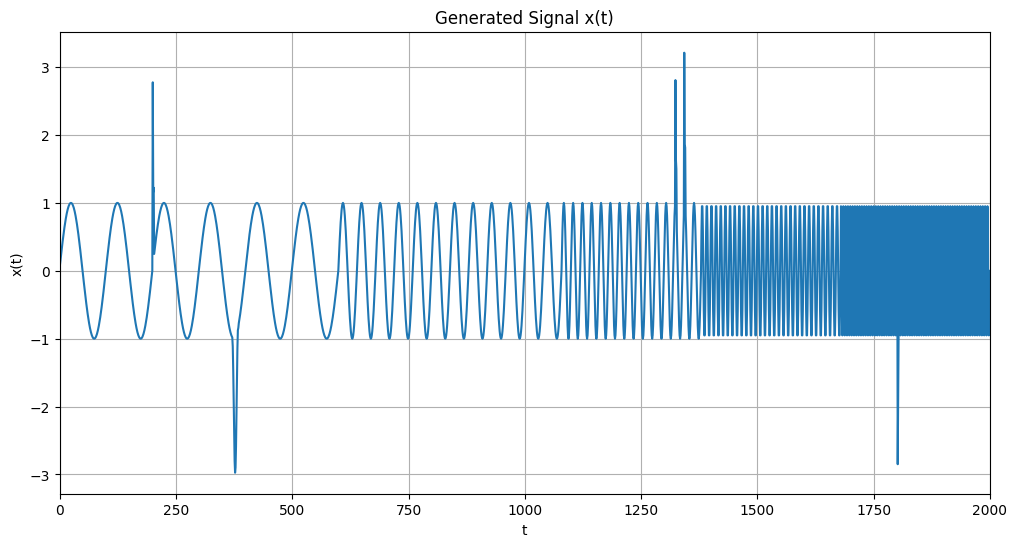

In [11]:
import numpy as np
import matplotlib.pyplot as plt
N = 2000                                             # Signal length
t = np.arange(N + 1)                                 # Time values
x = np.zeros_like(t, dtype=np.float64)               # Initialize x as float to allow for sin wave additions

pos_sin = np.array([0, 600, 1080, 1380, 1680, 2000]) # Initial position for each sinusoid function
T_sin = np.array([100, 40, 20, 10, 5])               # Sampling period of each sinusoid function

for i in range(5):
    m = pos_sin[i]
    n = pos_sin[i+1]

    segment_length = n - m
    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n] = np.sin(2*np.pi*t_segment_values/T_sin[i])

amp_imp = np.array([3, -2, 2, 2.5, -2.5])
pos_imp = np.array([200, 372, 1324, 1343, 1802])
T_imp = np.array([5, 25, 5, 5, 5])

for i in range(5):
    m = pos_imp[i]
    relative_end_offset = int(T_imp[i] / 2)
    n = pos_imp[i] + relative_end_offset

    segment_length = n - m + 1
    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n+1] += amp_imp[i] * (np.sin(2 *np.pi*t_segment_values/T_imp[i]))**2

plt.figure(figsize=(12, 6))
plt.plot(t, x)
plt.title('Generated Signal x(t)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.xlim(0, N)
plt.grid(True)
plt.show()

=== Wavelet bior4.4 (7–9) ===

h0 - Análise passa-baixas  [10 coef.]:
  [ 0.        0.037828 -0.023849 -0.110624  0.377403  0.852699  0.377403
 -0.110624 -0.023849  0.037828]

h1 - Análise passa-altas   [10 coef.]:
  [-0.       -0.064539  0.040689  0.418092 -0.788486  0.418092  0.040689
 -0.064539 -0.        0.      ]

g0 - Síntese passa-baixas  [10 coef.]:
  [ 0.       -0.064539 -0.040689  0.418092  0.788486  0.418092 -0.040689
 -0.064539  0.        0.      ]

g1 - Síntese passa-altas   [10 coef.]:
  [ 0.       -0.037828 -0.023849  0.110624  0.377403 -0.852699  0.377403
  0.110624 -0.023849 -0.037828]

Gráfico salvo em questao_3b.png


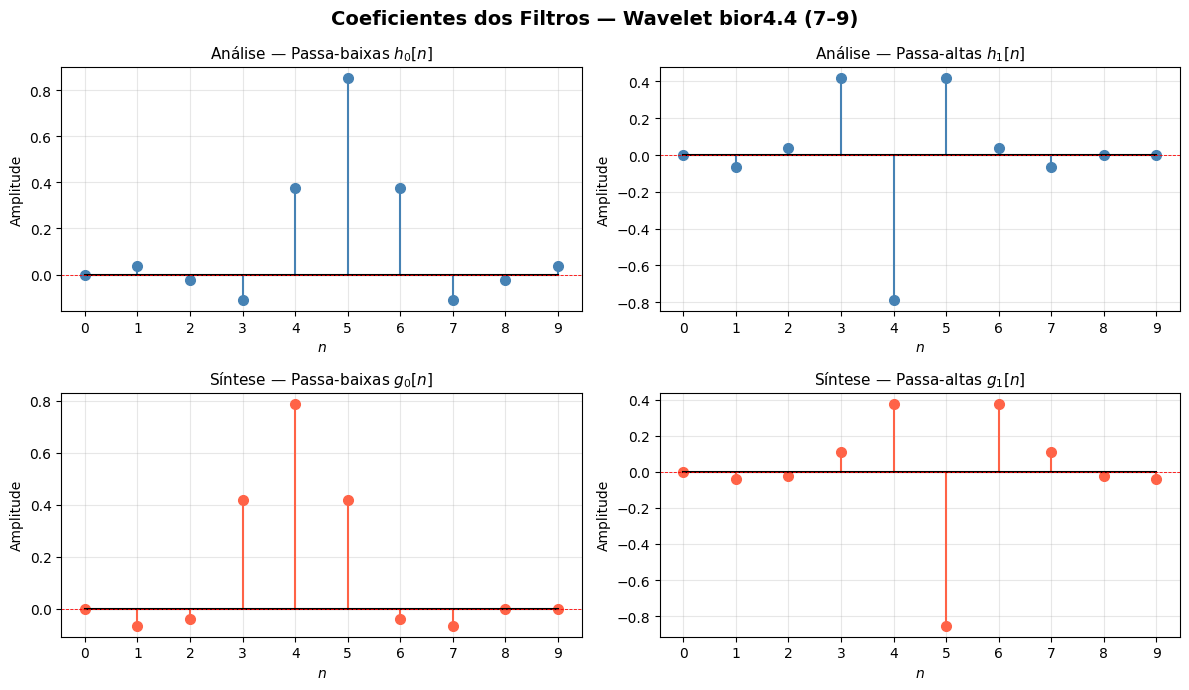

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# ── Wavelet bior4.4 ───────────────────────────────────────────────────────────
wavelet = pywt.Wavelet('bior4.4')

dec_lo = np.array(wavelet.dec_lo)   # h0 - análise passa-baixas  (9 coef.)
dec_hi = np.array(wavelet.dec_hi)   # h1 - análise passa-altas   (9 coef.)
rec_lo = np.array(wavelet.rec_lo)   # g0 - síntese passa-baixas  (7 coef.)
rec_hi = np.array(wavelet.rec_hi)   # g1 - síntese passa-altas   (7 coef.)

print("=== Wavelet bior4.4 (7–9) ===")
print(f"\nh0 - Análise passa-baixas  [{len(dec_lo)} coef.]:\n  {np.round(dec_lo, 6)}")
print(f"\nh1 - Análise passa-altas   [{len(dec_hi)} coef.]:\n  {np.round(dec_hi, 6)}")
print(f"\ng0 - Síntese passa-baixas  [{len(rec_lo)} coef.]:\n  {np.round(rec_lo, 6)}")
print(f"\ng1 - Síntese passa-altas   [{len(rec_hi)} coef.]:\n  {np.round(rec_hi, 6)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Coeficientes dos Filtros — Wavelet bior4.4 (7–9)", fontsize=14, fontweight='bold')

filters = [
    (dec_lo, r"Análise — Passa-baixas $h_0[n]$",  axes[0, 0], 'steelblue'),
    (dec_hi, r"Análise — Passa-altas $h_1[n]$",   axes[0, 1], 'steelblue'),
    (rec_lo, r"Síntese — Passa-baixas $g_0[n]$",  axes[1, 0], 'tomato'),
    (rec_hi, r"Síntese — Passa-altas $g_1[n]$",   axes[1, 1], 'tomato'),
]

for coeffs, title, ax, color in filters:
    n = np.arange(len(coeffs))
    markerline, stemlines, baseline = ax.stem(n, coeffs, basefmt='k-')
    plt.setp(stemlines, color=color, linewidth=1.5)
    plt.setp(markerline, color=color, markersize=7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("$n$")
    ax.set_ylabel("Amplitude")
    ax.axhline(0, color='red', linewidth=0.6, linestyle='--')
    ax.set_xticks(n)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("questao_3b.png", dpi=150, bbox_inches='tight')
print("\nGráfico salvo em questao_3b.png")
plt.show()

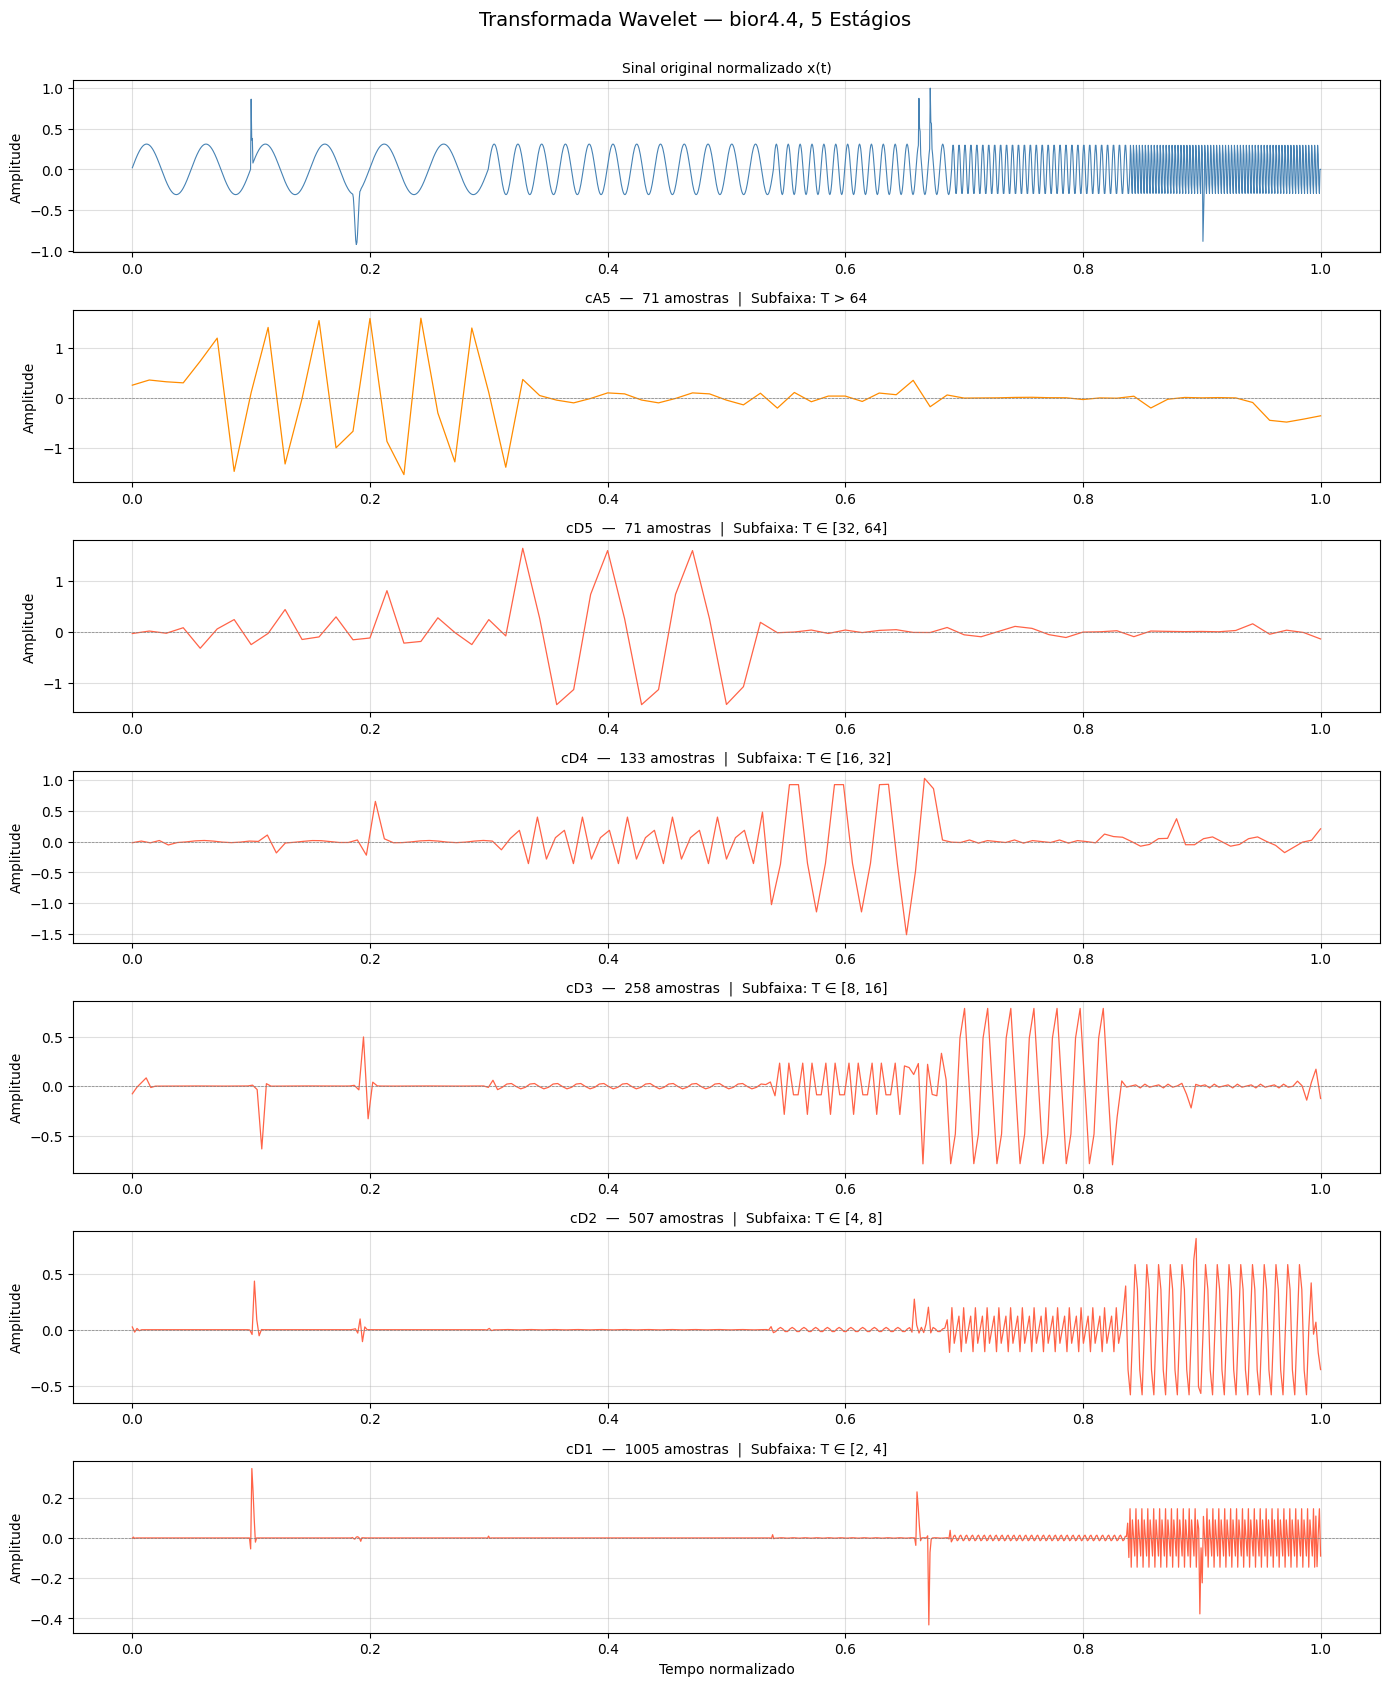

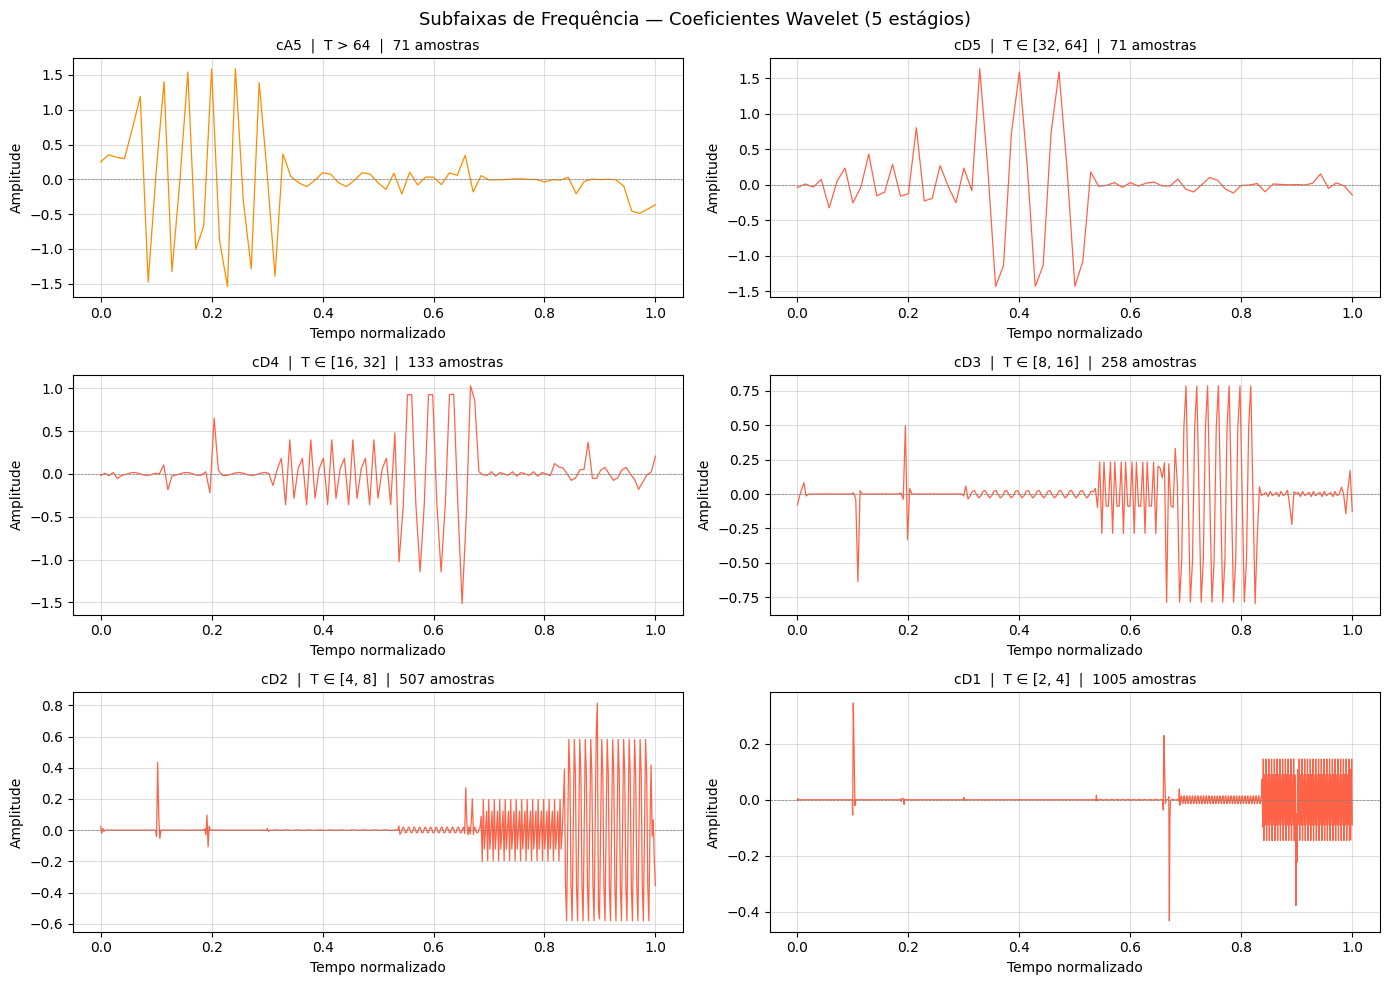


Nível  | # amostras |     Subfaixa freq. |    Energia | Max |coef|
-----------------------------------------------------------------
cA5    |         71 |             T > 64 |    27.1605 |     1.5886
cD5    |         71 |       T ∈ [32, 64] |    20.5371 |     1.6329
cD4    |        133 |       T ∈ [16, 32] |    17.1672 |     1.5138
cD3    |        258 |        T ∈ [8, 16] |    15.6685 |     0.7951
cD2    |        507 |         T ∈ [4, 8] |    17.6580 |     0.8143
cD1    |       1005 |         T ∈ [2, 4] |     2.5626 |     0.4327

Coeficientes de aproximação cA5 (71 valores):
[ 2.4910e-01  3.5230e-01  3.1680e-01  2.9550e-01  7.2830e-01  1.1899e+00
 -1.4761e+00  1.0010e-01  1.4041e+00 -1.3273e+00 -1.5800e-02  1.5414e+00
 -1.0040e+00 -6.7340e-01  1.5827e+00 -8.7540e-01 -1.5397e+00  1.5886e+00
 -3.0810e-01 -1.2856e+00  1.3927e+00  1.0030e-01 -1.3929e+00  3.6360e-01
  4.1200e-02 -5.0500e-02 -1.0490e-01 -1.6600e-02  9.4600e-02  7.5100e-02
 -4.8200e-02 -1.0490e-01 -1.6600e-02  9.4600e-02  7.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# ──────────────────────────────────────────────
# 1. REPRODUÇÃO DO SINAL (mesmo script original)
# ──────────────────────────────────────────────
N = 2000
t = np.arange(N + 1)
x = np.zeros_like(t, dtype=np.float64)

pos_sin = np.array([0, 600, 1080, 1380, 1680, 2000])
T_sin   = np.array([100, 40, 20, 10, 5])

for i in range(5):
    m = pos_sin[i]
    n = pos_sin[i+1]
    t_seg = np.arange(1, n - m + 1)
    x[m:n] = np.sin(2 * np.pi * t_seg / T_sin[i])

amp_imp = np.array([3, -2, 2, 2.5, -2.5])
pos_imp = np.array([200, 372, 1324, 1343, 1802])
T_imp   = np.array([5, 25, 5, 5, 5])

for i in range(5):
    m = pos_imp[i]
    n = pos_imp[i] + int(T_imp[i] / 2)
    t_seg = np.arange(1, n - m + 2)
    x[m:n+1] += amp_imp[i] * (np.sin(2 * np.pi * t_seg / T_imp[i])) ** 2

# Normalização
x_norm = x / np.max(np.abs(x))

# ──────────────────────────────────────────────
# 2. TRANSFORMADA WAVELET — 5 ESTÁGIOS, bior4.4
# ──────────────────────────────────────────────
wavelet = 'bior4.4'
level   = 5

coeffs = pywt.wavedec(x_norm, wavelet, level=level)
# coeffs = [cA5, cD5, cD4, cD3, cD2, cD1]

labels = [f'cA{level}'] + [f'cD{level - i}' for i in range(level)]

# ──────────────────────────────────────────────
# 3. SUBFAIXAS DE FREQUÊNCIA
#    Para fs = 1 (amostras normalizadas), a frequência de Nyquist é 0.5
#    Cada nível divide a banda por 2:
#      cD1: [0.25,  0.50]  →  T ∈ [2,   4]
#      cD2: [0.125, 0.25]  →  T ∈ [4,   8]
#      cD3: [0.063, 0.125] →  T ∈ [8,  16]
#      cD4: [0.031, 0.063] →  T ∈ [16, 32]
#      cD5: [0.016, 0.031] →  T ∈ [32, 64]
#      cA5: [0,     0.016] →  T > 64
# ──────────────────────────────────────────────
freq_bands = {
    'cA5': (0,      0.016,  'T > 64'),
    'cD5': (0.016,  0.031,  'T ∈ [32, 64]'),
    'cD4': (0.031,  0.063,  'T ∈ [16, 32]'),
    'cD3': (0.063,  0.125,  'T ∈ [8, 16]'),
    'cD2': (0.125,  0.25,   'T ∈ [4, 8]'),
    'cD1': (0.25,   0.5,    'T ∈ [2, 4]'),
}

# ──────────────────────────────────────────────
# 4. PLOT PRINCIPAL — sinal + coeficientes
# ──────────────────────────────────────────────
n_plots = level + 2
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 2.4 * n_plots))
fig.suptitle('Transformada Wavelet — bior4.4, 5 Estágios', fontsize=14, y=1.001)

# Sinal original
t_norm = np.linspace(0, 1, len(x_norm))
axes[0].plot(t_norm, x_norm, color='steelblue', linewidth=0.8)
axes[0].set_title('Sinal original normalizado x(t)', fontsize=10)
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.4)

# Coeficientes
for idx, (coef, label) in enumerate(zip(coeffs, labels)):
    ax    = axes[idx + 1]
    t_c   = np.linspace(0, 1, len(coef))
    color = 'darkorange' if 'cA' in label else 'tomato'

    ax.plot(t_c, coef, color=color, linewidth=0.9)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

    band_info = freq_bands.get(label, ('', '', ''))
    ax.set_title(
        f'{label}  —  {len(coef)} amostras  |  Subfaixa: {band_info[2]}',
        fontsize=10
    )
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel('Tempo normalizado')
plt.tight_layout()
plt.savefig('wavelet_5stages_item_c.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 5. PLOT DAS SUBFAIXAS (resumo visual)
# ──────────────────────────────────────────────
fig2, axes2 = plt.subplots(3, 2, figsize=(14, 10))
fig2.suptitle('Subfaixas de Frequência — Coeficientes Wavelet (5 estágios)', fontsize=13)
axes2 = axes2.flatten()

for idx, (coef, label) in enumerate(zip(coeffs, labels)):
    ax    = axes2[idx]
    t_c   = np.linspace(0, 1, len(coef))
    color = 'darkorange' if 'cA' in label else 'tomato'
    band_info = freq_bands.get(label, ('', '', ''))

    ax.plot(t_c, coef, color=color, linewidth=0.9)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(f'{label}  |  {band_info[2]}  |  {len(coef)} amostras', fontsize=10)
    ax.set_xlabel('Tempo normalizado')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('wavelet_subbands_item_c.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 6. TABELA DETALHADA
# ──────────────────────────────────────────────
print(f"\n{'Nível':<6} | {'# amostras':>10} | {'Subfaixa freq.':>18} | {'Energia':>10} | {'Max |coef|':>10}")
print("-" * 65)
for coef, label in zip(coeffs, labels):
    band_info = freq_bands.get(label, ('', '', label))
    energia   = np.sum(coef**2)
    print(f"{label:<6} | {len(coef):>10} | {band_info[2]:>18} | {energia:>10.4f} | {np.max(np.abs(coef)):>10.4f}")

# ──────────────────────────────────────────────
# 7. COEFICIENTES DE APROXIMAÇÃO (cA5)
# ──────────────────────────────────────────────
print(f"\nCoeficientes de aproximação cA5 ({len(coeffs[0])} valores):")
print(np.round(coeffs[0], 4))

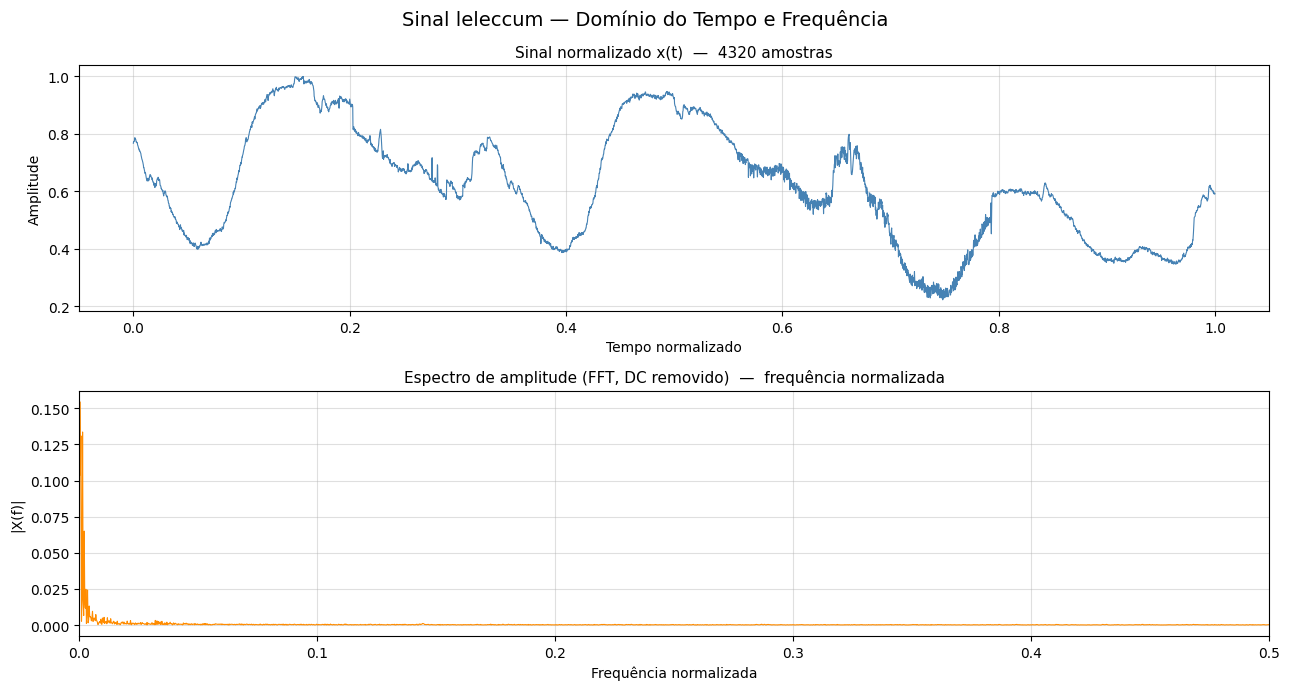

Número de amostras : 4320
Média do sinal     : 0.6202  (removida antes da FFT)
Desvio padrão      : 0.1967
Mínimo normalizado : 0.2225
Máximo normalizado : 1.0000


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.fft import fft, fftfreq

# ──────────────────────────────────────────────
# 1. CARREGAMENTO DO SINAL
# ──────────────────────────────────────────────
mat  = sio.loadmat('leleccum.mat')
x    = mat['leleccum'].flatten()
N    = len(x)                        # 4320 amostras

# Normalização
x_norm = x / np.max(np.abs(x))

# Remoção do DC (componente média)
x_ac = x_norm - np.mean(x_norm)

# Eixo de tempo normalizado
t = np.linspace(0, 1, N)

# ──────────────────────────────────────────────
# 2. ESPECTRO (FFT sem DC)
# ──────────────────────────────────────────────
X     = fft(x_ac)
freqs = fftfreq(N)

# Apenas lado positivo
half      = N // 2
freqs_pos = freqs[:half]
mag_pos   = (2 / N) * np.abs(X[:half])

# ──────────────────────────────────────────────
# 3. PLOT — sinal no tempo + espectro
# ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
fig.suptitle('Sinal leleccum — Domínio do Tempo e Frequência', fontsize=14)

# --- Sinal no tempo ---
axes[0].plot(t, x_norm, color='steelblue', linewidth=0.8)
axes[0].set_title('Sinal normalizado x(t)  —  4320 amostras', fontsize=11)
axes[0].set_xlabel('Tempo normalizado')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.4)

# --- Espectro (sem DC) ---
axes[1].plot(freqs_pos, mag_pos, color='darkorange', linewidth=0.8)
axes[1].set_title(
    'Espectro de amplitude (FFT, DC removido)  —  frequência normalizada',
    fontsize=11
)
axes[1].set_xlabel('Frequência normalizada')
axes[1].set_ylabel('|X(f)|')
axes[1].set_xlim([0, 0.5])
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('leleccum_item_a_corrigido.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 4. ESTATÍSTICAS
# ──────────────────────────────────────────────
print(f"Número de amostras : {N}")
print(f"Média do sinal     : {x_norm.mean():.4f}  (removida antes da FFT)")
print(f"Desvio padrão      : {x_norm.std():.4f}")
print(f"Mínimo normalizado : {x_norm.min():.4f}")
print(f"Máximo normalizado : {x_norm.max():.4f}")

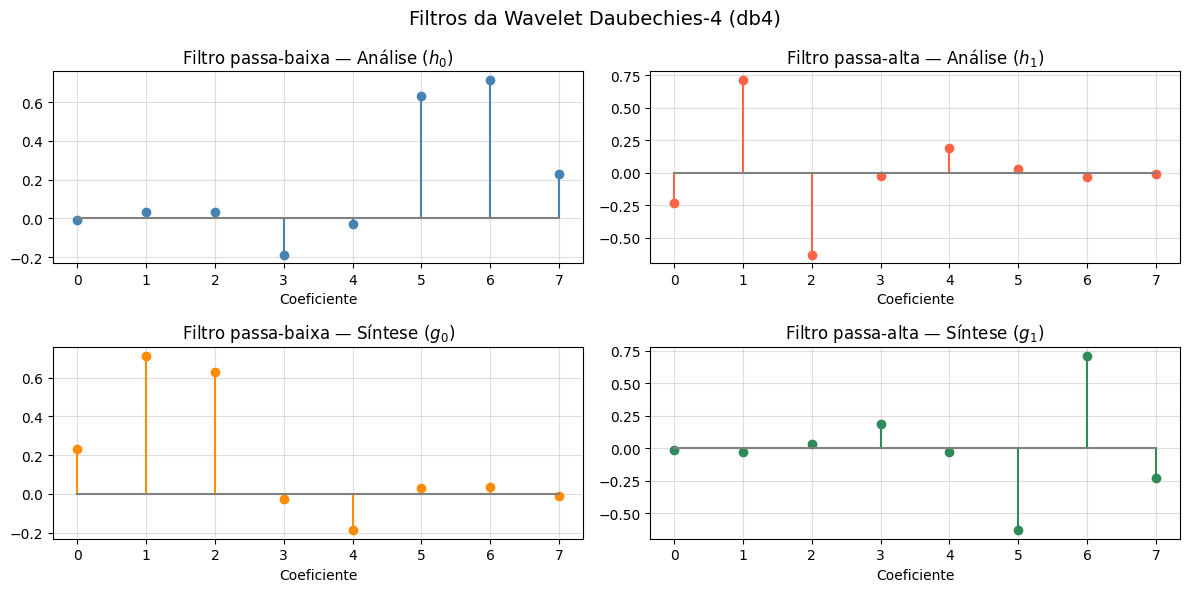

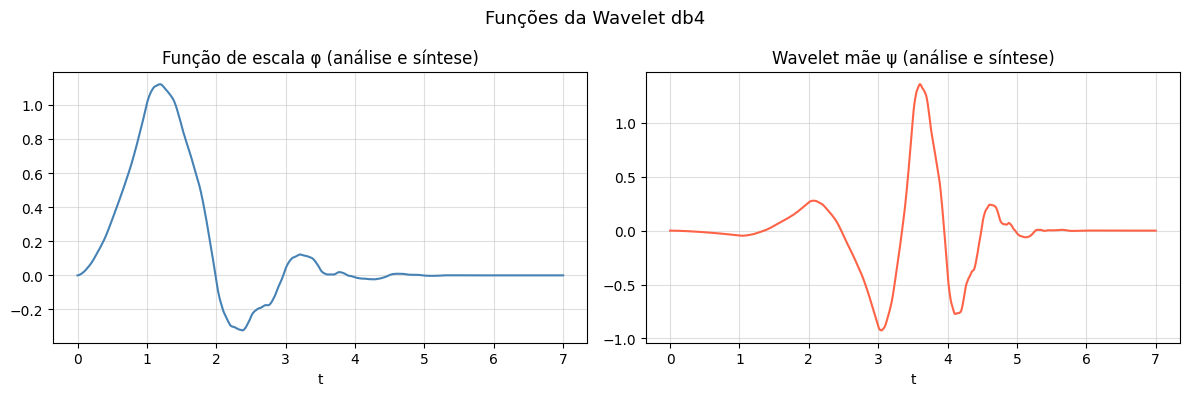

Wavelet: db4  |  Comprimento dos filtros: 8

   n |    h0 (análise PB) |    h1 (análise PA)
----------------------------------------------
   0 |        -0.01059740 |        -0.23037781
   1 |         0.03288301 |         0.71484657
   2 |         0.03084138 |        -0.63088077
   3 |        -0.18703481 |        -0.02798377
   4 |        -0.02798377 |         0.18703481
   5 |         0.63088077 |         0.03084138
   6 |         0.71484657 |        -0.03288301
   7 |         0.23037781 |        -0.01059740

   n |    g0 (síntese PB) |    g1 (síntese PA)
----------------------------------------------
   0 |         0.23037781 |        -0.01059740
   1 |         0.71484657 |        -0.03288301
   2 |         0.63088077 |         0.03084138
   3 |        -0.02798377 |         0.18703481
   4 |        -0.18703481 |        -0.02798377
   5 |         0.03084138 |        -0.63088077
   6 |         0.03288301 |         0.71484657
   7 |        -0.01059740 |        -0.23037781

Propriedades 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pywt

# ──────────────────────────────────────────────
# 1. CARREGAMENTO E NORMALIZAÇÃO DO SINAL
# ──────────────────────────────────────────────
mat    = sio.loadmat('leleccum.mat')
x      = mat['leleccum'].flatten()
N      = len(x)                      # 4320 amostras
x_norm = x / np.max(np.abs(x))
t      = np.linspace(0, 1, N)

# ──────────────────────────────────────────────
# 2. WAVELET db4 — FILTROS DE ANÁLISE E SÍNTESE
# ──────────────────────────────────────────────
wavelet = pywt.Wavelet('db4')

# Filtros de análise
lo_d = np.array(wavelet.dec_lo)   # passa-baixa  (análise)
hi_d = np.array(wavelet.dec_hi)   # passa-alta   (análise)

# Filtros de síntese
lo_r = np.array(wavelet.rec_lo)   # passa-baixa  (síntese)
hi_r = np.array(wavelet.rec_hi)   # passa-alta   (síntese)

# ──────────────────────────────────────────────
# 3. PLOT DOS FILTROS
# ──────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 2, figsize=(12, 6))
fig1.suptitle('Filtros da Wavelet Daubechies-4 (db4)', fontsize=14)

idx_lo_d = np.arange(len(lo_d))
idx_hi_d = np.arange(len(hi_d))
idx_lo_r = np.arange(len(lo_r))
idx_hi_r = np.arange(len(hi_r))

axes1[0, 0].stem(idx_lo_d, lo_d, basefmt='gray', linefmt='steelblue', markerfmt='o')
axes1[0, 0].set_title('Filtro passa-baixa — Análise ($h_0$)')
axes1[0, 0].set_xlabel('Coeficiente')
axes1[0, 0].grid(True, alpha=0.4)

axes1[0, 1].stem(idx_hi_d, hi_d, basefmt='gray', linefmt='tomato', markerfmt='o')
axes1[0, 1].set_title('Filtro passa-alta — Análise ($h_1$)')
axes1[0, 1].set_xlabel('Coeficiente')
axes1[0, 1].grid(True, alpha=0.4)

axes1[1, 0].stem(idx_lo_r, lo_r, basefmt='gray', linefmt='darkorange', markerfmt='o')
axes1[1, 0].set_title('Filtro passa-baixa — Síntese ($g_0$)')
axes1[1, 0].set_xlabel('Coeficiente')
axes1[1, 0].grid(True, alpha=0.4)

axes1[1, 1].stem(idx_hi_r, hi_r, basefmt='gray', linefmt='seagreen', markerfmt='o')
axes1[1, 1].set_title('Filtro passa-alta — Síntese ($g_1$)')
axes1[1, 1].set_xlabel('Coeficiente')
axes1[1, 1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('leleccum_db4_filtros_b.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 4. FUNÇÕES DE ESCALA E WAVELET MÃE
# ──────────────────────────────────────────────
phi, psi, x_wav = wavelet.wavefun(level=10)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle('Funções da Wavelet db4', fontsize=13)

axes2[0].plot(x_wav, phi, color='steelblue', linewidth=1.5)
axes2[0].set_title('Função de escala φ (análise e síntese)')
axes2[0].set_xlabel('t')
axes2[0].grid(True, alpha=0.4)

axes2[1].plot(x_wav, psi, color='tomato', linewidth=1.5)
axes2[1].set_title('Wavelet mãe ψ (análise e síntese)')
axes2[1].set_xlabel('t')
axes2[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('leleccum_db4_funcoes_b.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 5. TABELA DOS COEFICIENTES DOS FILTROS
# ──────────────────────────────────────────────
print("=" * 60)
print(f"Wavelet: {wavelet.name}  |  Comprimento dos filtros: {wavelet.filter_bank[0].__len__()}")
print("=" * 60)
print(f"\n{'n':>4} | {'h0 (análise PB)':>18} | {'h1 (análise PA)':>18}")
print("-" * 46)
for n, (h0, h1) in enumerate(zip(lo_d, hi_d)):
    print(f"{n:>4} | {h0:>18.8f} | {h1:>18.8f}")

print(f"\n{'n':>4} | {'g0 (síntese PB)':>18} | {'g1 (síntese PA)':>18}")
print("-" * 46)
for n, (g0, g1) in enumerate(zip(lo_r, hi_r)):
    print(f"{n:>4} | {g0:>18.8f} | {g1:>18.8f}")

# ──────────────────────────────────────────────
# 6. PROPRIEDADES DA WAVELET
# ──────────────────────────────────────────────
print(f"\nPropriedades da db4:")
print(f"  Momentos nulos      : {wavelet.vanishing_moments_psi}")
print(f"  Comprimento suporte : {wavelet.dec_len - 1}")
print(f"  Ortogonal           : {wavelet.orthogonal}")
print(f"  Biortogonal         : {wavelet.biorthogonal}")

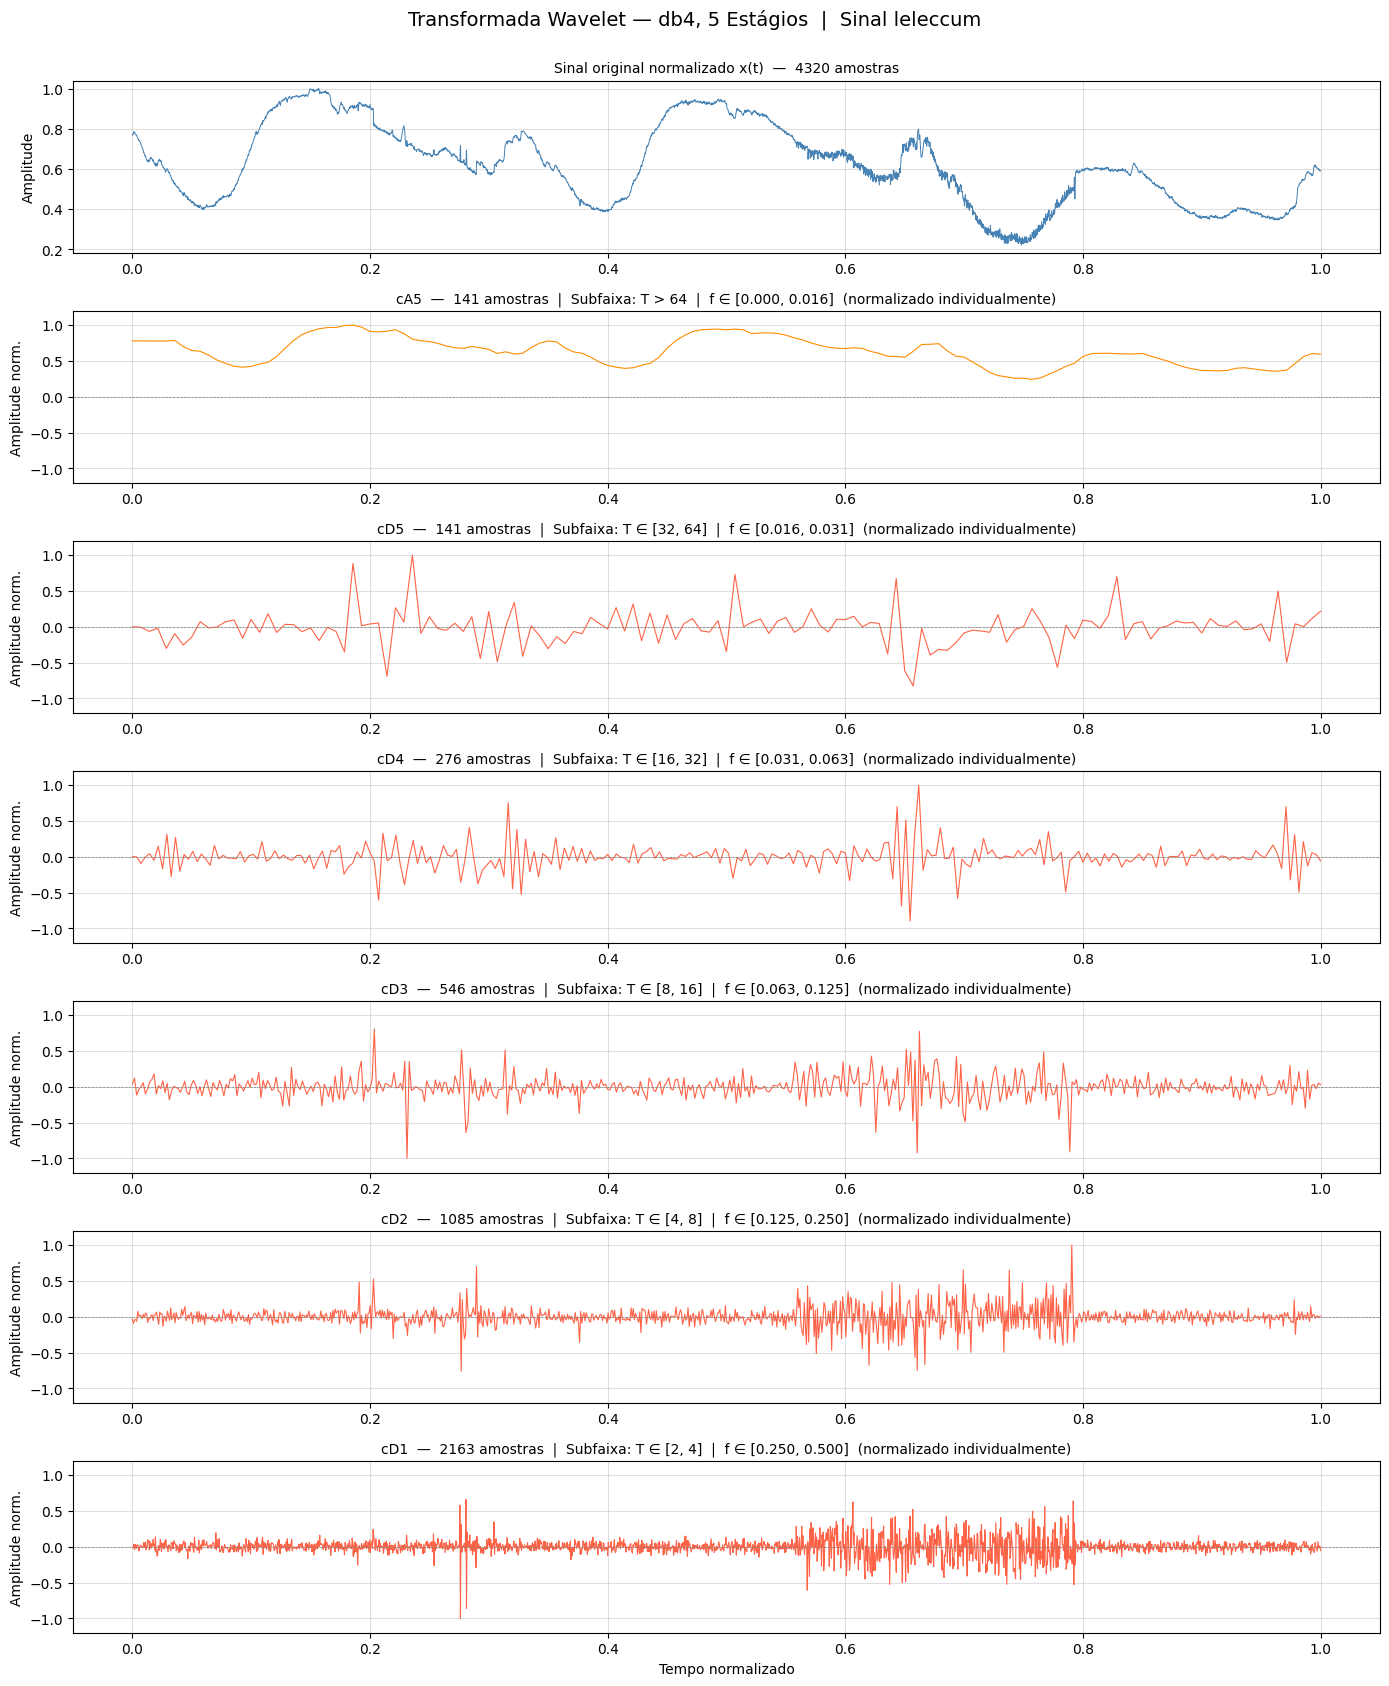

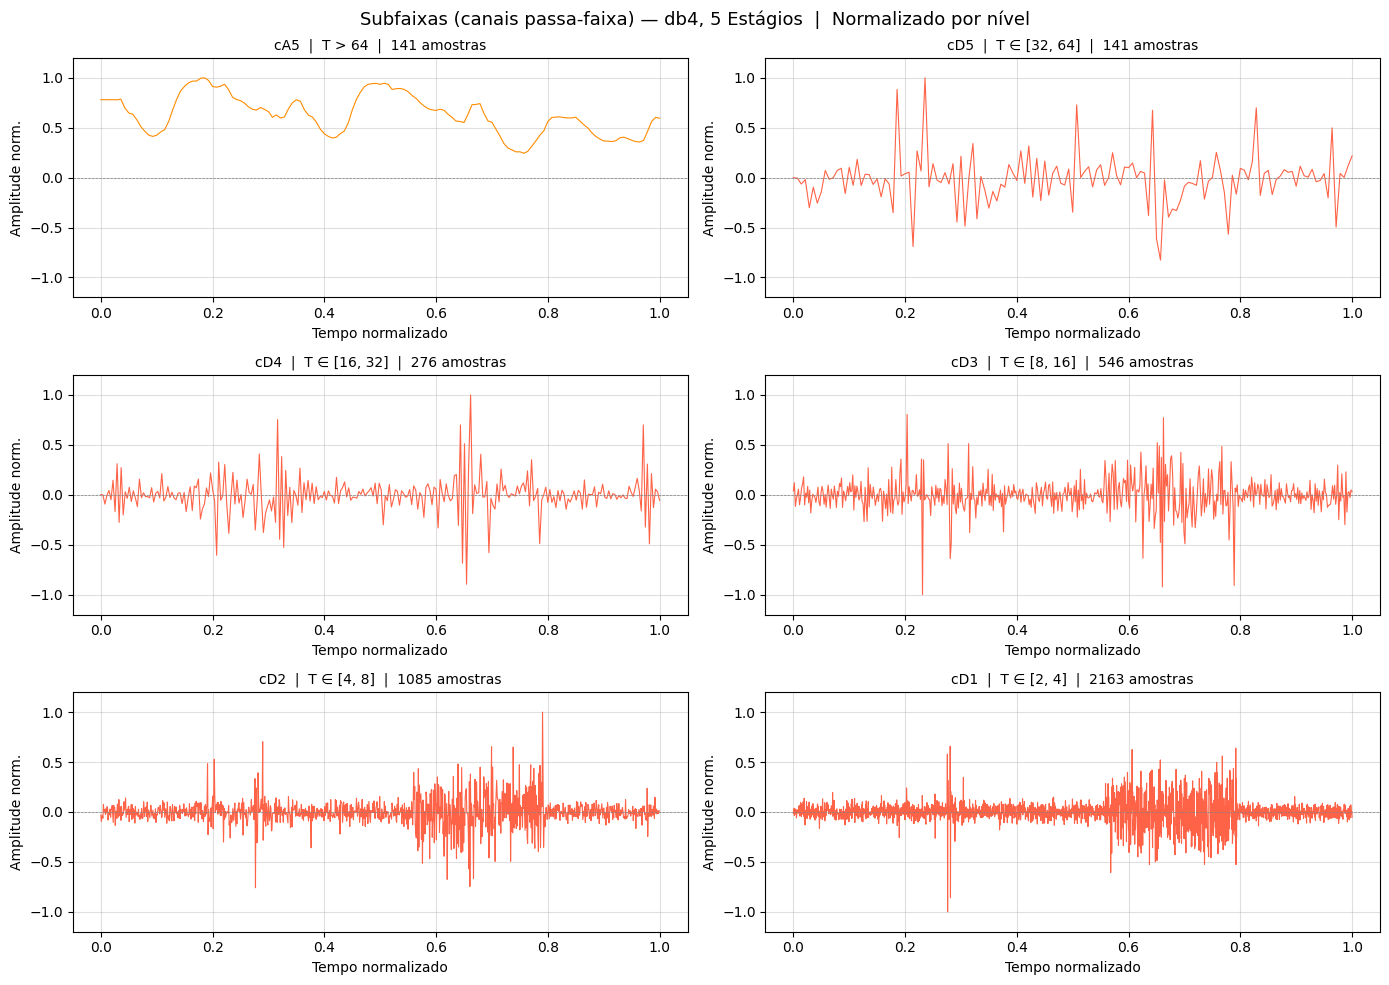


Nível  | # amostras |         Subfaixa |    Energia |  % Energia |  Max|coef|
-------------------------------------------------------------------------
cA5    |        141 |           T > 64 |  1937.5924 |     99.97% |     5.6072
cD5    |        141 |     T ∈ [32, 64] |     0.2505 |      0.01% |     0.1677
cD4    |        276 |     T ∈ [16, 32] |     0.1328 |      0.01% |     0.1149
cD3    |        546 |      T ∈ [8, 16] |     0.0709 |      0.00% |     0.0666
cD2    |       1085 |       T ∈ [4, 8] |     0.0778 |      0.00% |     0.0602
cD1    |       2163 |       T ∈ [2, 4] |     0.0927 |      0.00% |     0.0556


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pywt

# ──────────────────────────────────────────────
# 1. CARREGAMENTO E NORMALIZAÇÃO DO SINAL
# ──────────────────────────────────────────────
mat    = sio.loadmat('leleccum.mat')
x      = mat['leleccum'].flatten()
N      = len(x)                      # 4320 amostras
x_norm = x / np.max(np.abs(x))
t      = np.linspace(0, 1, N)

# ──────────────────────────────────────────────
# 2. TRANSFORMADA WAVELET — db4, 5 ESTÁGIOS
# ──────────────────────────────────────────────
wavelet = 'db4'
level   = 5

coeffs = pywt.wavedec(x_norm, wavelet, level=level)
# coeffs = [cA5, cD5, cD4, cD3, cD2, cD1]
labels = [f'cA{level}'] + [f'cD{level - i}' for i in range(level)]

# Normalização individual por nível (para comparação visual justa)
coeffs_plot = [c / np.max(np.abs(c)) if np.max(np.abs(c)) > 0 else c for c in coeffs]

# ──────────────────────────────────────────────
# 3. SUBFAIXAS DE FREQUÊNCIA
# ──────────────────────────────────────────────
freq_bands = {
    'cA5': (0.000, 0.016, 'T > 64'),
    'cD5': (0.016, 0.031, 'T ∈ [32, 64]'),
    'cD4': (0.031, 0.063, 'T ∈ [16, 32]'),
    'cD3': (0.063, 0.125, 'T ∈ [8, 16]'),
    'cD2': (0.125, 0.250, 'T ∈ [4, 8]'),
    'cD1': (0.250, 0.500, 'T ∈ [2, 4]'),
}

# ──────────────────────────────────────────────
# 4. PLOT PRINCIPAL — sinal + coeficientes normalizados
# ──────────────────────────────────────────────
n_plots = level + 2
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 2.4 * n_plots))
fig.suptitle('Transformada Wavelet — db4, 5 Estágios  |  Sinal leleccum', fontsize=14, y=1.001)

# Sinal original
axes[0].plot(t, x_norm, color='steelblue', linewidth=0.7)
axes[0].set_title('Sinal original normalizado x(t)  —  4320 amostras', fontsize=10)
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.4)

# Coeficientes por nível
for idx, (coef, label) in enumerate(zip(coeffs_plot, labels)):
    ax    = axes[idx + 1]
    t_c   = np.linspace(0, 1, len(coef))
    color = 'darkorange' if 'cA' in label else 'tomato'
    band  = freq_bands.get(label, ('', '', label))

    ax.plot(t_c, coef, color=color, linewidth=0.8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(
        f'{label}  —  {len(coef)} amostras  |  Subfaixa: {band[2]}  '
        f'|  f ∈ [{band[0]:.3f}, {band[1]:.3f}]  (normalizado individualmente)',
        fontsize=10
    )
    ax.set_ylabel('Amplitude norm.')
    ax.set_ylim([-1.2, 1.2])
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel('Tempo normalizado')
plt.tight_layout()
plt.savefig('leleccum_wavelet5_item_c_corrigido.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 5. PLOT GRADE — subfaixas isoladas (3×2)
# ──────────────────────────────────────────────
fig2, axes2 = plt.subplots(3, 2, figsize=(14, 10))
fig2.suptitle('Subfaixas (canais passa-faixa) — db4, 5 Estágios  |  Normalizado por nível', fontsize=13)
axes2 = axes2.flatten()

for idx, (coef, label) in enumerate(zip(coeffs_plot, labels)):
    ax    = axes2[idx]
    t_c   = np.linspace(0, 1, len(coef))
    color = 'darkorange' if 'cA' in label else 'tomato'
    band  = freq_bands.get(label, ('', '', label))

    ax.plot(t_c, coef, color=color, linewidth=0.8)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(f'{label}  |  {band[2]}  |  {len(coeffs[idx])} amostras', fontsize=10)
    ax.set_xlabel('Tempo normalizado')
    ax.set_ylabel('Amplitude norm.')
    ax.set_ylim([-1.2, 1.2])
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('leleccum_subbands_item_c_corrigido.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 6. TABELA — energia e amplitude por subfaixa
# ──────────────────────────────────────────────
energia_total = sum(np.sum(c**2) for c in coeffs)

print(f"\n{'Nível':<6} | {'# amostras':>10} | {'Subfaixa':>16} | {'Energia':>10} | {'% Energia':>10} | {'Max|coef|':>10}")
print("-" * 73)
for coef, label in zip(coeffs, labels):
    band    = freq_bands.get(label, ('', '', label))
    energia = np.sum(coef**2)
    pct     = 100 * energia / energia_total
    print(f"{label:<6} | {len(coef):>10} | {band[2]:>16} | {energia:>10.4f} | {pct:>9.2f}% | {np.max(np.abs(coef)):>10.4f}")

Estimativa de ruído:
  σ estimado (MAD)   : 0.003409
  Limiar universal   : 0.013948


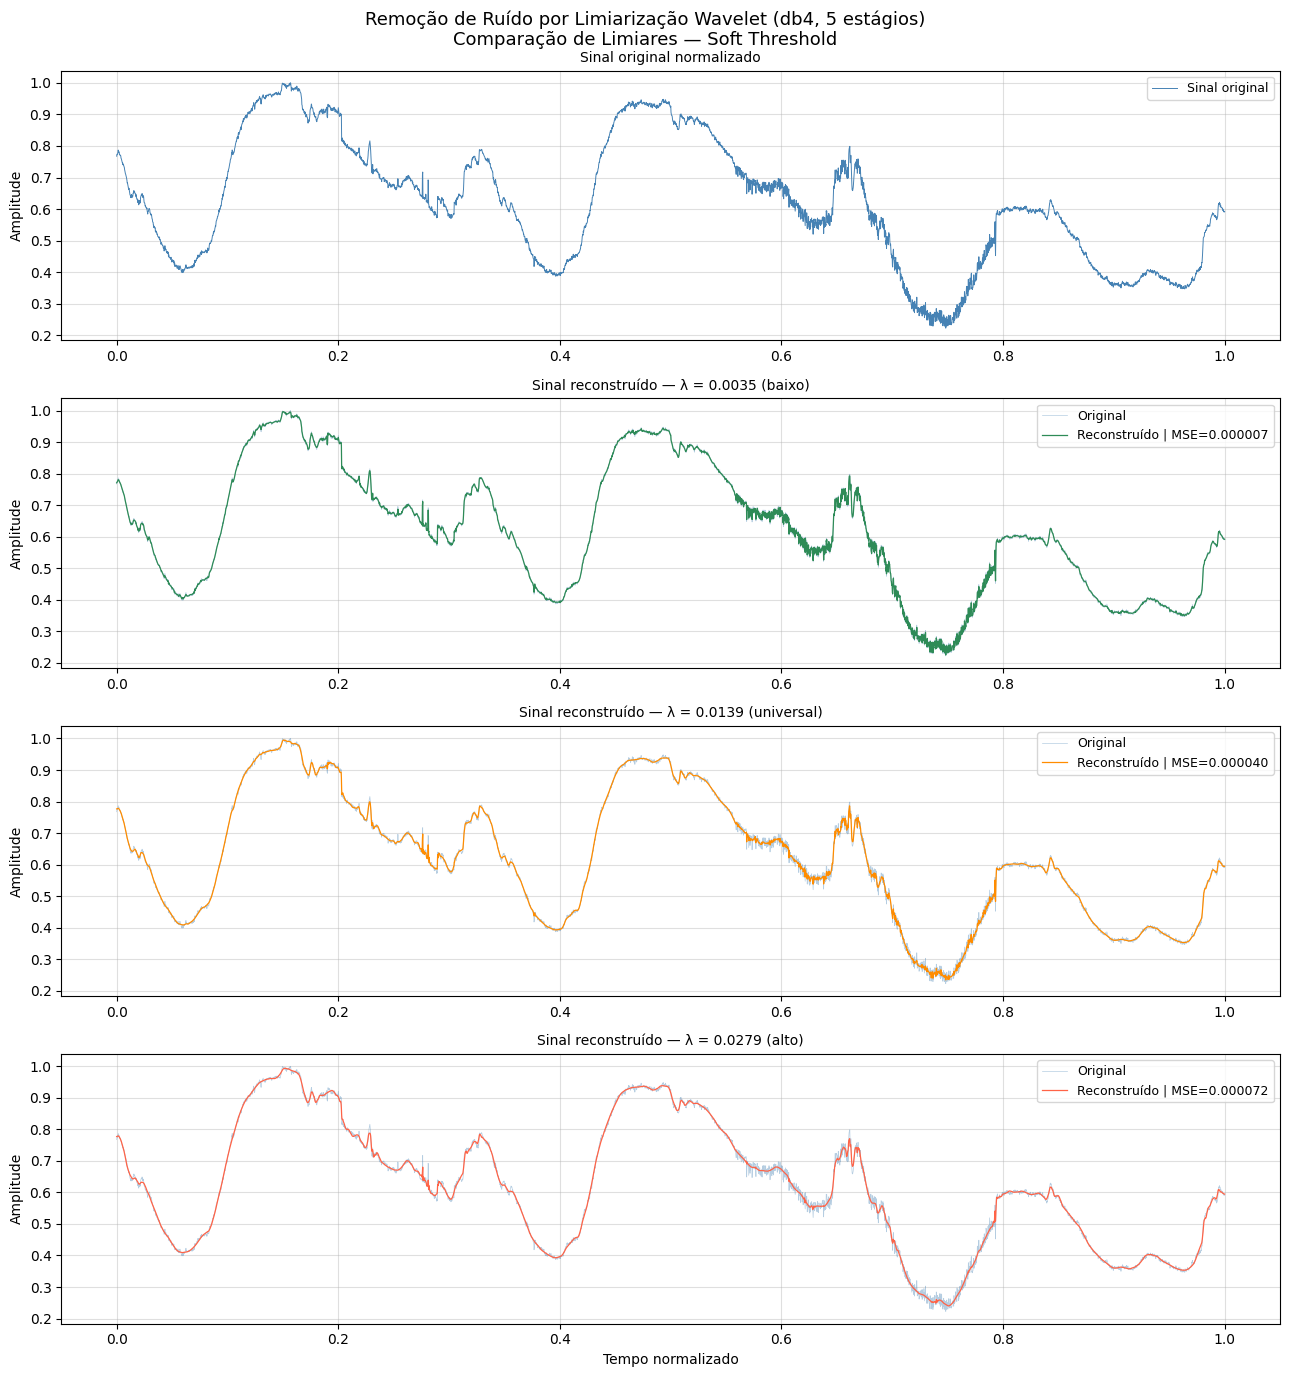

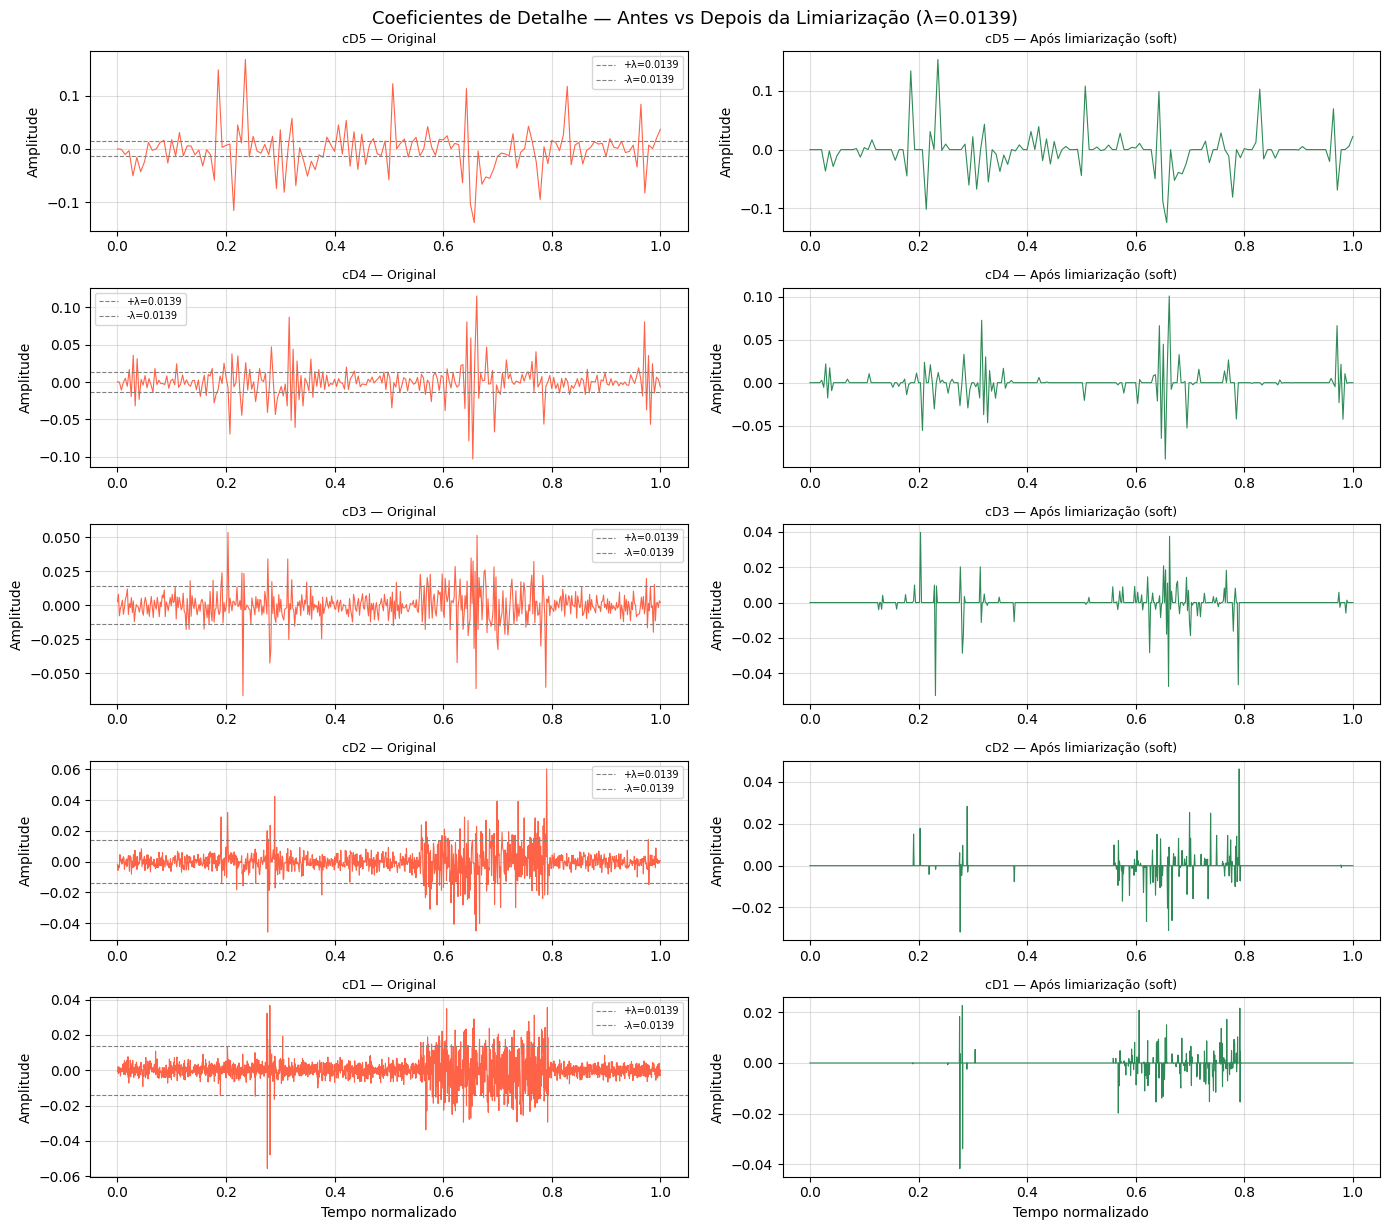


Limiar                                   |        MSE |   SNR (dB)
-----------------------------------------------------------------
λ = 0.0035 (baixo)                       |   0.000007 |      47.69
λ = 0.0139 (universal)                   |   0.000040 |      40.19
λ = 0.0279 (alto)                        |   0.000072 |      37.72


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pywt

# ──────────────────────────────────────────────
# 1. CARREGAMENTO E NORMALIZAÇÃO DO SINAL
# ──────────────────────────────────────────────
mat    = sio.loadmat('leleccum.mat')
x      = mat['leleccum'].flatten()
N      = len(x)
x_norm = x / np.max(np.abs(x))
t      = np.linspace(0, 1, N)

# ──────────────────────────────────────────────
# 2. DECOMPOSIÇÃO — db4, 5 ESTÁGIOS
# ──────────────────────────────────────────────
wavelet = 'db4'
level   = 5
coeffs  = pywt.wavedec(x_norm, wavelet, level=level)

# ──────────────────────────────────────────────
# 3. FUNÇÃO DE LIMIARIZAÇÃO (THRESHOLDING)
#    Soft threshold: sign(x) * max(|x| - λ, 0)
#    Hard threshold: x se |x| > λ, 0 caso contrário
# ──────────────────────────────────────────────
def denoise(coeffs, threshold, mode='soft'):
    """Aplica limiarização nos coeficientes de detalhe (mantém cA intacto)."""
    coeffs_den = [coeffs[0]]  # mantém aproximação (cA5) sem modificar
    for c in coeffs[1:]:
        coeffs_den.append(pywt.threshold(c, threshold, mode=mode))
    return coeffs_den

# ──────────────────────────────────────────────
# 4. LIMIARES A TESTAR
# ──────────────────────────────────────────────
# Limiar universal de Donoho-Johnstone: λ = σ * sqrt(2 * log(N))
# Estimativa de σ pelo nível cD1 (MAD estimator)
sigma_est = np.median(np.abs(coeffs[-1])) / 0.6745
lambda_universal = sigma_est * np.sqrt(2 * np.log(N))

thresholds = {
    f'λ = {lambda_universal/4:.4f} (baixo)' : lambda_universal / 4,
    f'λ = {lambda_universal:.4f} (universal)': lambda_universal,
    f'λ = {lambda_universal*2:.4f} (alto)'   : lambda_universal * 2,
}

print("Estimativa de ruído:")
print(f"  σ estimado (MAD)   : {sigma_est:.6f}")
print(f"  Limiar universal   : {lambda_universal:.6f}")

# ──────────────────────────────────────────────
# 5. RECONSTRUÇÃO E PLOT — comparação dos limiares
# ──────────────────────────────────────────────
fig, axes = plt.subplots(len(thresholds) + 1, 1, figsize=(13, 3.5 * (len(thresholds) + 1)))
fig.suptitle('Remoção de Ruído por Limiarização Wavelet (db4, 5 estágios)\nComparação de Limiares — Soft Threshold', fontsize=13)

# Sinal original
axes[0].plot(t, x_norm, color='steelblue', linewidth=0.7, label='Sinal original')
axes[0].set_title('Sinal original normalizado', fontsize=10)
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

colors = ['seagreen', 'darkorange', 'tomato']
x_den_list = {}

for ax, (label, thr), color in zip(axes[1:], thresholds.items(), colors):
    coeffs_den = denoise(coeffs, thr, mode='soft')
    x_den      = pywt.waverec(coeffs_den, wavelet)[:N]
    x_den_list[label] = x_den

    # MSE em relação ao sinal original
    mse = np.mean((x_norm - x_den) ** 2)

    ax.plot(t, x_norm, color='steelblue', linewidth=0.5, alpha=0.4, label='Original')
    ax.plot(t, x_den,  color=color,       linewidth=0.9, label=f'Reconstruído | MSE={mse:.6f}')
    ax.set_title(f'Sinal reconstruído — {label}', fontsize=10)
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel('Tempo normalizado')
plt.tight_layout()
plt.savefig('leleccum_denoising_item_d.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 6. PLOT — coeficientes antes e depois (limiar universal)
# ──────────────────────────────────────────────
thr_uni   = list(thresholds.values())[1]
coeffs_den_uni = denoise(coeffs, thr_uni, mode='soft')
labels_det = [f'cD{level - i}' for i in range(level)]

fig2, axes2 = plt.subplots(level, 2, figsize=(14, 2.5 * level))
fig2.suptitle(f'Coeficientes de Detalhe — Antes vs Depois da Limiarização (λ={thr_uni:.4f})', fontsize=13)

for i in range(level):
    c_orig = coeffs[i + 1]
    c_den  = coeffs_den_uni[i + 1]
    t_c    = np.linspace(0, 1, len(c_orig))
    label  = labels_det[i]

    axes2[i, 0].plot(t_c, c_orig, color='tomato', linewidth=0.8)
    axes2[i, 0].axhline(thr_uni,  color='gray', linestyle='--', linewidth=0.8, label=f'+λ={thr_uni:.4f}')
    axes2[i, 0].axhline(-thr_uni, color='gray', linestyle='--', linewidth=0.8, label=f'-λ={thr_uni:.4f}')
    axes2[i, 0].set_title(f'{label} — Original', fontsize=9)
    axes2[i, 0].set_ylabel('Amplitude')
    axes2[i, 0].legend(fontsize=7)
    axes2[i, 0].grid(True, alpha=0.4)

    axes2[i, 1].plot(t_c, c_den, color='seagreen', linewidth=0.8)
    axes2[i, 1].set_title(f'{label} — Após limiarização (soft)', fontsize=9)
    axes2[i, 1].set_ylabel('Amplitude')
    axes2[i, 1].grid(True, alpha=0.4)

axes2[-1, 0].set_xlabel('Tempo normalizado')
axes2[-1, 1].set_xlabel('Tempo normalizado')
plt.tight_layout()
plt.savefig('leleccum_coefs_denoising_item_d.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 7. TABELA — comparação dos limiares
# ──────────────────────────────────────────────
print(f"\n{'Limiar':<40} | {'MSE':>10} | {'SNR (dB)':>10}")
print("-" * 65)
for label, x_den in x_den_list.items():
    mse = np.mean((x_norm - x_den) ** 2)
    snr = 10 * np.log10(np.mean(x_norm**2) / mse) if mse > 0 else float('inf')
    print(f"{label:<40} | {mse:>10.6f} | {snr:>10.2f}")

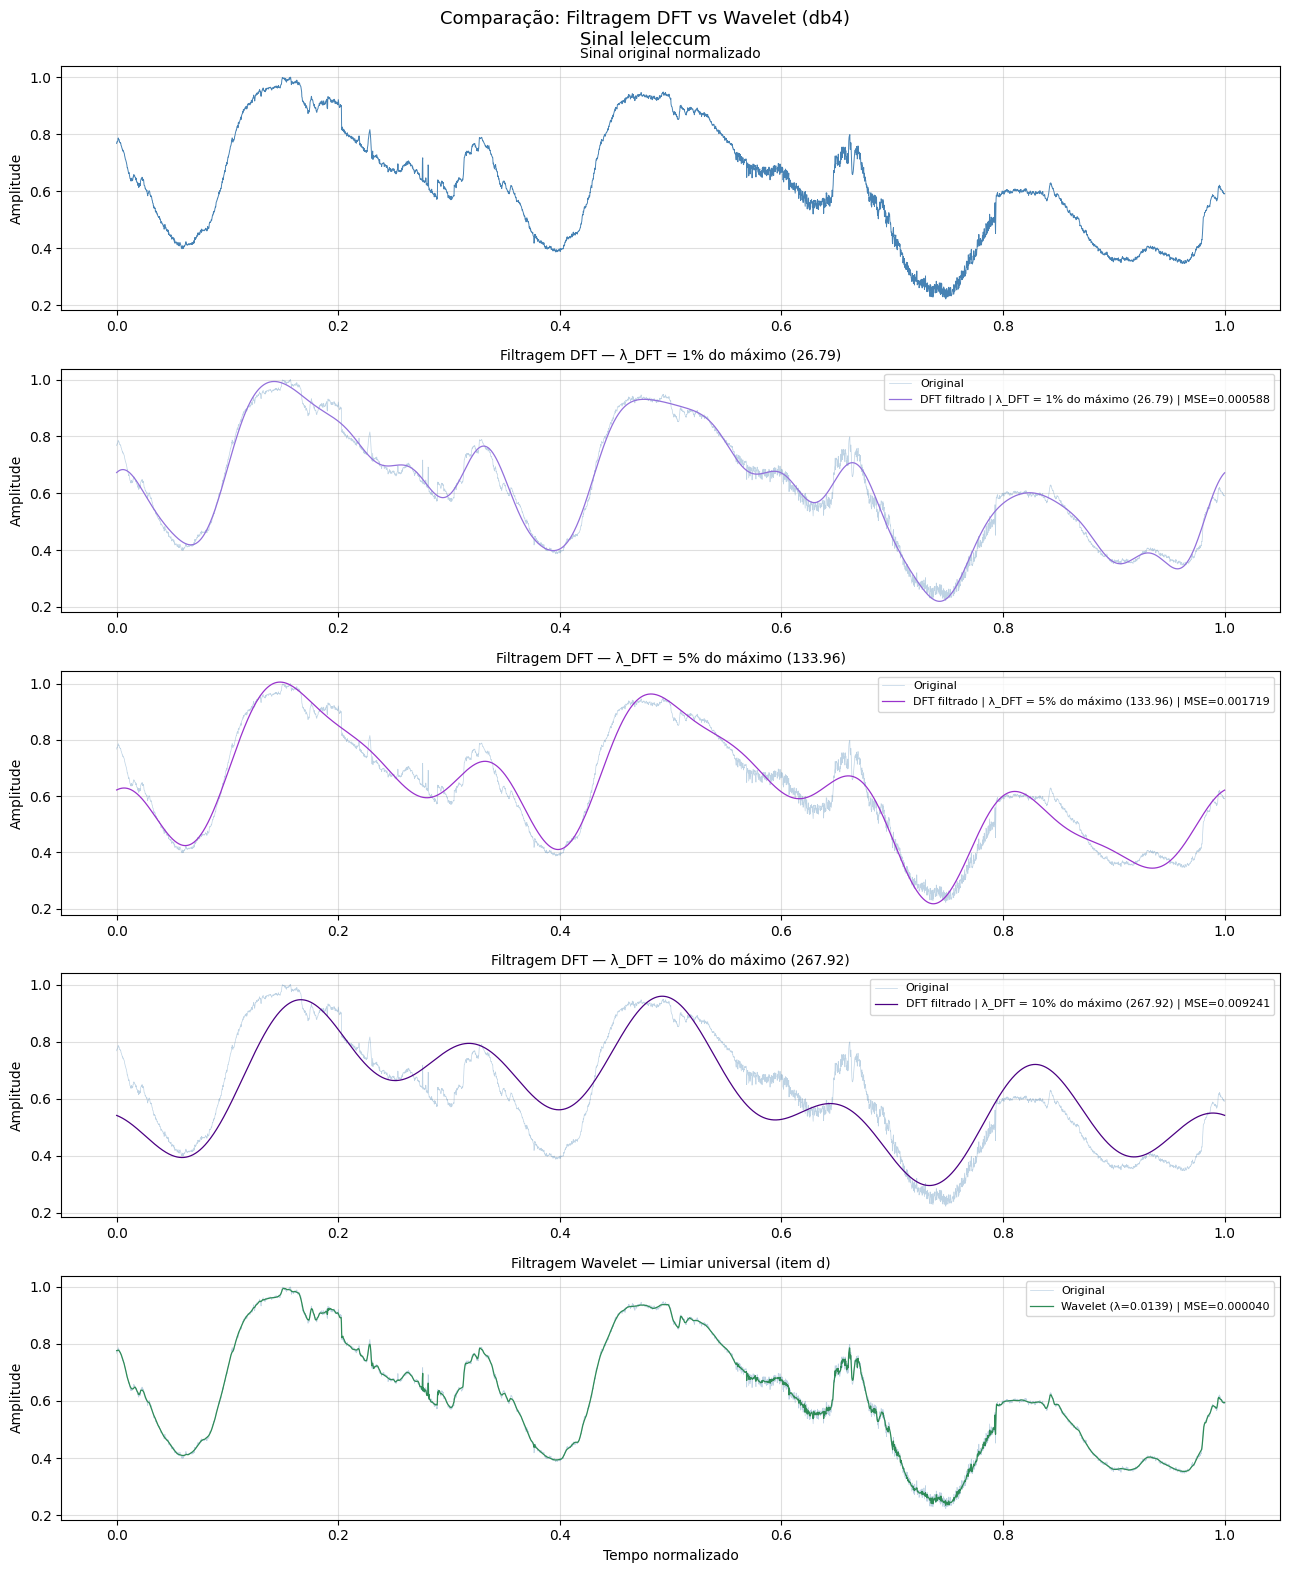

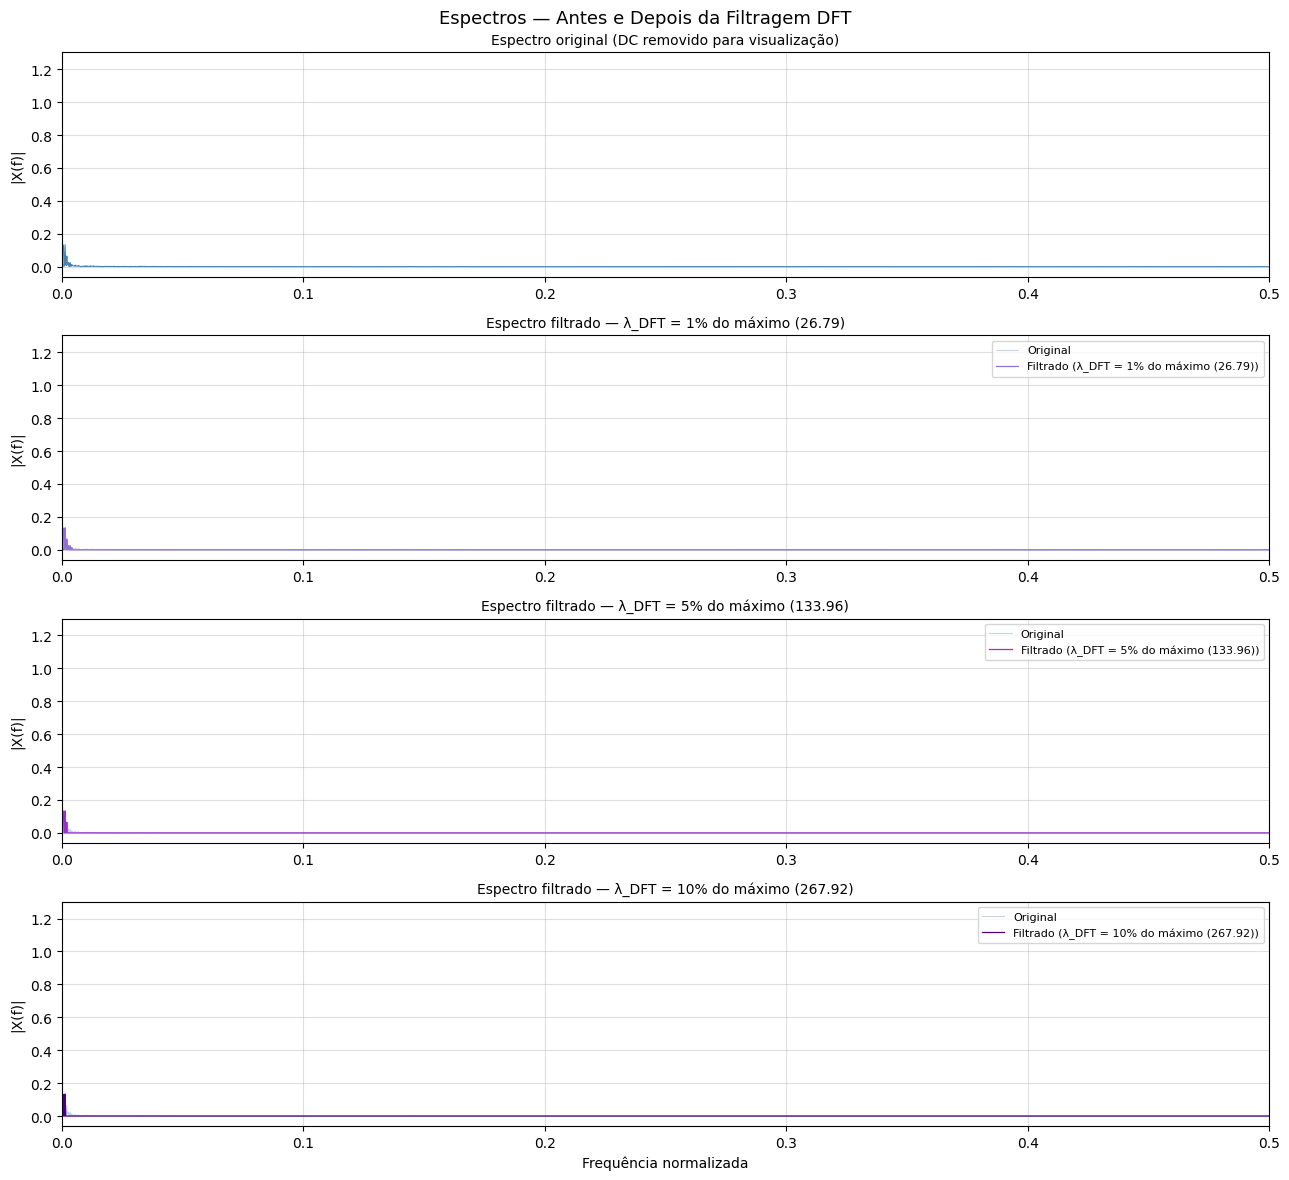


Método                                        |        MSE |   SNR (dB) |  Coef. mantidos
------------------------------------------------------------------------------------------
DFT: λ_DFT = 1% do máximo (26.79)             |   0.000588 |      28.58 |              23
DFT: λ_DFT = 5% do máximo (133.96)            |   0.001719 |      23.91 |              11
DFT: λ_DFT = 10% do máximo (267.92)           |   0.009241 |      16.61 |               7
Wavelet: λ universal (item d)                 |   0.000040 |      40.19 |             606


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pywt
from scipy.fft import fft, ifft, fftfreq

# ──────────────────────────────────────────────
# 1. CARREGAMENTO E NORMALIZAÇÃO DO SINAL
# ──────────────────────────────────────────────
mat    = sio.loadmat('leleccum.mat')
x      = mat['leleccum'].flatten()
N      = len(x)
x_norm = x / np.max(np.abs(x))
t      = np.linspace(0, 1, N)

# ──────────────────────────────────────────────
# 2. RECONSTRUÇÃO WAVELET (item d — limiar universal)
#    para comparação direta com DFT
# ──────────────────────────────────────────────
wavelet  = 'db4'
level    = 5
coeffs   = pywt.wavedec(x_norm, wavelet, level=level)

sigma_est       = np.median(np.abs(coeffs[-1])) / 0.6745
lambda_universal = sigma_est * np.sqrt(2 * np.log(N))

coeffs_den = [coeffs[0]]
for c in coeffs[1:]:
    coeffs_den.append(pywt.threshold(c, lambda_universal, mode='soft'))
x_wav = pywt.waverec(coeffs_den, wavelet)[:N]

# ──────────────────────────────────────────────
# 3. FILTRAGEM POR LIMIARIZAÇÃO NA DFT
#    Estratégia: zerar componentes espectrais com
#    magnitude abaixo de um limiar λ_dft
# ──────────────────────────────────────────────
X      = fft(x_norm)
freqs  = fftfreq(N)
mag    = np.abs(X)

# Limiares DFT a testar (fração da magnitude máxima)
fractions = [0.01, 0.05, 0.10]
x_dft_list = {}

for frac in fractions:
    lambda_dft = frac * np.max(mag)
    X_den      = X.copy()
    X_den[mag < lambda_dft] = 0          # zera componentes abaixo do limiar
    x_den_dft  = np.real(ifft(X_den))
    label      = f'λ_DFT = {frac*100:.0f}% do máximo ({lambda_dft:.2f})'
    x_dft_list[label] = (lambda_dft, x_den_dft)

# ──────────────────────────────────────────────
# 4. PLOT — comparação DFT vs Wavelet no tempo
# ──────────────────────────────────────────────
n_plots = len(fractions) + 2
fig, axes = plt.subplots(n_plots, 1, figsize=(13, 3.2 * n_plots))
fig.suptitle('Comparação: Filtragem DFT vs Wavelet (db4)\nSinal leleccum', fontsize=13)

# Sinal original
axes[0].plot(t, x_norm, color='steelblue', linewidth=0.7)
axes[0].set_title('Sinal original normalizado', fontsize=10)
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.4)

# DFT com diferentes limiares
colors_dft = ['mediumpurple', 'darkorchid', 'indigo']
for ax, (label, (lam, x_den)), color in zip(axes[1:-1], x_dft_list.items(), colors_dft):
    mse = np.mean((x_norm - x_den) ** 2)
    ax.plot(t, x_norm, color='steelblue', linewidth=0.5, alpha=0.35, label='Original')
    ax.plot(t, x_den,  color=color,       linewidth=0.9,
            label=f'DFT filtrado | {label} | MSE={mse:.6f}')
    ax.set_title(f'Filtragem DFT — {label}', fontsize=10)
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

# Wavelet (item d)
mse_wav = np.mean((x_norm - x_wav) ** 2)
axes[-1].plot(t, x_norm, color='steelblue', linewidth=0.5, alpha=0.35, label='Original')
axes[-1].plot(t, x_wav,  color='seagreen',  linewidth=0.9,
              label=f'Wavelet (λ={lambda_universal:.4f}) | MSE={mse_wav:.6f}')
axes[-1].set_title('Filtragem Wavelet — Limiar universal (item d)', fontsize=10)
axes[-1].set_ylabel('Amplitude')
axes[-1].set_xlabel('Tempo normalizado')
axes[-1].legend(fontsize=8)
axes[-1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('leleccum_dft_vs_wavelet_item_e.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 5. PLOT — espectros antes e depois da filtragem DFT
# ──────────────────────────────────────────────
half      = N // 2
freqs_pos = freqs[:half]
mag_orig  = (2/N) * np.abs(X[:half])

fig2, axes2 = plt.subplots(len(fractions) + 1, 1, figsize=(13, 3 * (len(fractions) + 1)))
fig2.suptitle('Espectros — Antes e Depois da Filtragem DFT', fontsize=13)

axes2[0].plot(freqs_pos, mag_orig, color='steelblue', linewidth=0.8)
axes2[0].set_title('Espectro original (DC removido para visualização)', fontsize=10)
axes2[0].set_ylabel('|X(f)|')
axes2[0].set_xlim([0, 0.5])
axes2[0].grid(True, alpha=0.4)

for ax, (label, (lam, x_den)), color in zip(axes2[1:], x_dft_list.items(), colors_dft):
    X_den_plot = fft(x_den)
    mag_den    = (2/N) * np.abs(X_den_plot[:half])
    componentes_mantidas = np.sum(np.abs(fft(x_den)) > 0)

    ax.plot(freqs_pos, mag_orig, color='steelblue', linewidth=0.6, alpha=0.4, label='Original')
    ax.plot(freqs_pos, mag_den,  color=color,       linewidth=0.9, label=f'Filtrado ({label})')
    ax.set_title(f'Espectro filtrado — {label}', fontsize=10)
    ax.set_ylabel('|X(f)|')
    ax.set_xlim([0, 0.5])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

axes2[-1].set_xlabel('Frequência normalizada')
plt.tight_layout()
plt.savefig('leleccum_espectros_item_e.png', dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────
# 6. TABELA COMPARATIVA
# ──────────────────────────────────────────────
print(f"\n{'Método':<45} | {'MSE':>10} | {'SNR (dB)':>10} | {'Coef. mantidos':>15}")
print("-" * 90)

# DFT
for label, (lam, x_den) in x_dft_list.items():
    mse  = np.mean((x_norm - x_den) ** 2)
    snr  = 10 * np.log10(np.mean(x_norm**2) / mse) if mse > 0 else float('inf')
    kept = np.sum(np.abs(fft(x_den)) > 1e-10)
    print(f"{'DFT: ' + label:<45} | {mse:>10.6f} | {snr:>10.2f} | {kept:>15}")

# Wavelet
mse_w  = np.mean((x_norm - x_wav) ** 2)
snr_w  = 10 * np.log10(np.mean(x_norm**2) / mse_w) if mse_w > 0 else float('inf')
kept_w = sum(np.sum(np.abs(c) > 1e-10) for c in coeffs_den)
print(f"{'Wavelet: λ universal (item d)':<45} | {mse_w:>10.6f} | {snr_w:>10.2f} | {kept_w:>15}")